# Pipeline NLP — Abstracts do arXiv

## Fase 1 — Pré-processamento

**Corpus:** 5 400 abstracts de 5 categorias do arXiv (`cs.LG`, `stat.ML`, `q-bio.NC`, `econ.EM`, `eess.SP`).

**Produto desta fase:** coluna `tokens_lemma` — sequência de lemas limpos por abstract — que alimenta todas as fases seguintes.

**Etapas:**
1. Carregamento e inspeção inicial
2. Limpeza de LaTeX
3. Tokenização (sentenças e palavras)
4. Remoção de stopwords
5. Stemming (Porter) × Lemmatização (spaCy) — comparação
6. POS tagging
7. Análise de impacto no vocabulário
8. Visualizações

> Execute as células de cima para baixo em ordem.


In [256]:
DOWNLOAD = False  # notebook reads local files only — never touches the network

import os
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 4)})
os.makedirs('outputs', exist_ok=True)
print('Setup OK')
CATEGORY_COLORS = {
    'cs.LG':    '#2E6DA4',   # azul-ardósia profundo
    'stat.ML':  '#3A8C7E',   # teal sóbrio
    'q-bio.NC': '#C05B4D',   # terracota
    'econ.EM':  '#C9972E',   # mostarda / ocre
    'eess.SP':  '#7B5EA7',   # roxo-acinzentado
}
CATEGORY_ORDER = ['cs.LG', 'stat.ML', 'q-bio.NC', 'econ.EM', 'eess.SP']

Setup OK


## 1.1 Carregamento e Inspeção Inicial


In [257]:
df = pd.read_parquet('data/corpus_raw.parquet')
print(f'Shape: {df.shape}')
df.head(2)


Shape: (5400, 6)


,id,title,abstract,primary_category,authors,published
0,2507.15774,Time Series Forecasting Through the Lens of Dynamics,"While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by ...",cs.LG,"[Alexis-Raja Brachet, Pierre-Yves Richard and C\'eline Hudelot]",2026-05-15
1,2510.27258,Higher-order Linear Attention,The quadratic cost of scaled dot-product attention is a central obstacle to scaling autoregressive language models t...,cs.LG,"[Yifan Zhang, Zhen Qin, Mengdi Wang, Quanquan Gu]",2026-05-15


In [258]:
print('Abstracts por categoria:')
print(df['primary_category'].value_counts().to_string())
print(f'\nTotal: {len(df)}')


Abstracts por categoria:
primary_category
cs.LG       2000
stat.ML     1200
eess.SP     1200
q-bio.NC     500
econ.EM      500

Total: 5400


In [259]:
df['n_words_raw'] = df['abstract'].str.split().str.len()

print('Estatísticas de comprimento (palavras brutas):')
print(df['n_words_raw'].describe().round(1).to_string())
print()
print('Média por categoria:')
print(df.groupby('primary_category')['n_words_raw'].mean().round(1)
        .sort_values(ascending=False).to_string())


Estatísticas de comprimento (palavras brutas):
count    5400.0
mean      176.7
std        44.1
min        14.0
25%       147.0
50%       176.0
75%       207.0
max       300.0

Média por categoria:
primary_category
q-bio.NC    189.4
cs.LG       182.6
eess.SP     177.7
stat.ML     171.1
econ.EM     151.5


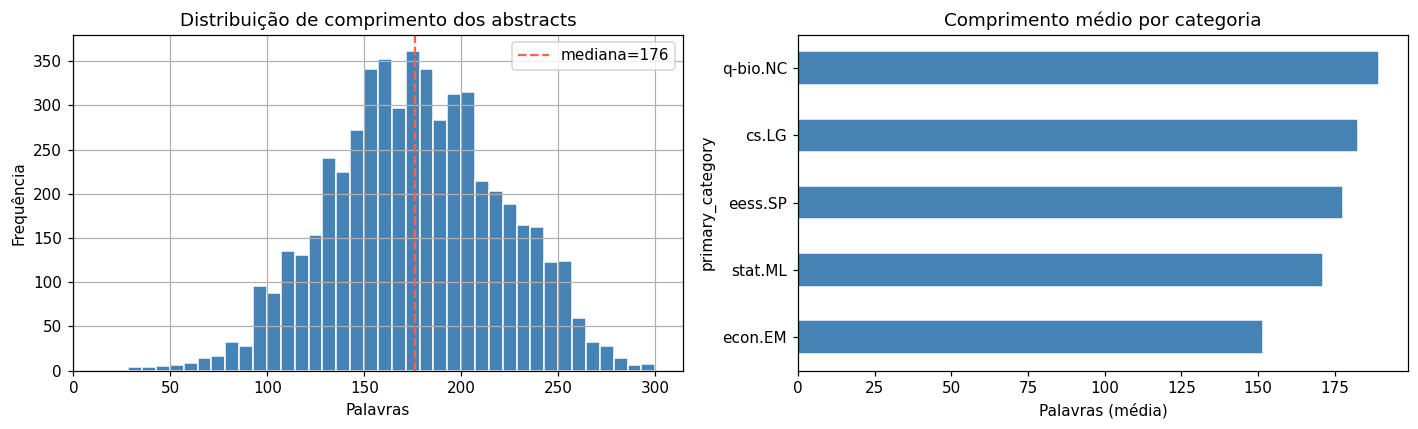

In [260]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['n_words_raw'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
med = df['n_words_raw'].median()
axes[0].axvline(med, color='tomato', linestyle='--', label=f'mediana={med:.0f}')
axes[0].set_title('Distribuição de comprimento dos abstracts')
axes[0].set_xlabel('Palavras'); axes[0].set_ylabel('Frequência')
axes[0].legend()

(df.groupby('primary_category')['n_words_raw'].mean()
   .sort_values()
   .plot.barh(ax=axes[1], color='steelblue', edgecolor='white'))
axes[1].set_title('Comprimento médio por categoria')
axes[1].set_xlabel('Palavras (média)')

plt.tight_layout()
plt.savefig('outputs/fig_abstract_lengths.png', bbox_inches='tight')
plt.show()


## 1.2 Limpeza de LaTeX

Abstracts do arXiv contêm marcação LaTeX extensiva: equações `$...$` e `$$...$$`,
citações `\cite{...}`, referências `\ref{...}`, comandos de formatação
(`\textbf`, `\emph`, `\mathbf`) e letras gregas avulsas (`\alpha`, `\beta`).

**Por que limpar antes de tokenizar?**
Sem limpeza o vocabulário enche de fragmentos sem conteúdo semântico:
`_{n}`, `\sigma_k`, `\mathbf`, `x^2`. Esses artefatos inflamam o tamanho
do vocabulário, prejudicam o TF-IDF e tornam os tópicos do LDA/NMF ilegíveis.
Esta etapa é crítica e deve anteceder qualquer tokenização.


In [261]:
def clean_latex(text: str) -> str:
    # display math $$...$$
    text = re.sub(r'\$\$.*?\$\$', ' ', text, flags=re.DOTALL)
    # inline math $...$
    text = re.sub(r'\$[^$\n]*?\$', ' ', text)
    # \cite{}, \ref{}, \label{}, \eqref{}
    text = re.sub(r'\\(?:cite|ref|label|eqref|bibitem)\{[^}]*\}', '', text, flags=re.IGNORECASE)
    # \begin{}...\end{} environments
    text = re.sub(r'\\begin\{[^}]*\}.*?\\end\{[^}]*\}', ' ', text, flags=re.DOTALL)
    # commands with arguments: \textbf{}, \mathbf{}, \emph{}
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    # remaining standalone commands: \alpha, \beta, \le
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    # stray braces
    text = re.sub(r'[{}]', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Demonstration on a LaTeX-heavy abstract
mask = df['abstract'].str.contains(r'\$', na=False)
raw_sample = df.loc[mask, 'abstract'].iloc[0]
print('ANTES:\n', raw_sample[:400])
print('\nDEPOIS:\n', clean_latex(raw_sample)[:400])


ANTES:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original $\texttt{PRO-DYN}$ nomenclature to analyze existing models 

DEPOIS:
 While deep learning is facing an homogenization across modalities led by Transformers, they are still challenged by shallow linear models in the time series forecasting task. Our hypothesis is that models should learn a direct link from past to future data points, which we identify as a learning dynamics capability. We develop an original nomenclature to analyze existing models through the lens of


In [262]:
df['abstract_clean'] = df['abstract'].apply(clean_latex)

# Sanity-check: very few dollar signs should remain
remaining = df['abstract_clean'].str.contains(r'\$', na=False).sum()
print(f'Abstracts com "$" após limpeza: {remaining}  (esperado ≈ 0)')


Abstracts com "$" após limpeza: 3  (esperado ≈ 0)


## 1.3 Tokenização

Usamos NLTK para dois níveis:
- **Sentenças** (`sent_tokenize`): relevante para o NER da Fase 4.
- **Palavras** (`word_tokenize`): mantemos apenas tokens alfabéticos, em minúsculas. Pontuação, números e artefatos não-alfa são descartados aqui.


In [263]:
# Sentence tokenization — example
sample_clean = df['abstract_clean'].iloc[0]
sents = sent_tokenize(sample_clean)
print(f'Sentenças no 1.º abstract: {len(sents)}')
for s in sents[:3]:
    print(' •', s[:110])

# Word tokenization
def tokenize(text: str) -> list:
    return [t.lower() for t in word_tokenize(text) if t.isalpha()]

df['tokens_raw'] = df['abstract_clean'].apply(tokenize)

vocab_raw = len({t for toks in df['tokens_raw'] for t in toks})
avg_len   = df['tokens_raw'].apply(len).mean()
print(f'\nVocabulário bruto : {vocab_raw:,} tipos únicos')
print(f'Comprimento médio : {avg_len:.1f} tokens/abstract')


Sentenças no 1.º abstract: 6
 • While deep learning is facing an homogenization across modalities led by Transformers, they are still challeng
 • Our hypothesis is that models should learn a direct link from past to future data points, which we identify as
 • We develop an original nomenclature to analyze existing models through the lens of dynamics.

Vocabulário bruto : 21,835 tipos únicos
Comprimento médio : 165.7 tokens/abstract


## 1.4 Remoção de Stopwords

Combinamos duas listas:
- **NLTK English stopwords** (artigos, preposições, pronomes).
- **Stopwords de domínio** (customizadas): termos ubíquos em abstracts
  científicos sem poder discriminativo entre categorias — *paper*, *propose*,
  *result*, *approach*, *show*, *method*, *present*, *use*, *work*, *study*.

**O que NÃO removemos:** termos de conteúdo que são descritores temáticos
essenciais: *model*, *network*, *regression*, *learning*, *algorithm*,
*distribution*, *estimation*, *neural*, *graph*. Removê-los destruiria a
capacidade discriminativa do corpus entre as 5 categorias.


In [264]:
NLTK_STOPS = set(stopwords.words('english'))

DOMAIN_STOPS = {
    'paper', 'papers', 'propose', 'proposed', 'proposes', 'proposing',
    'result', 'results', 'approach', 'approaches',
    'show', 'shown', 'shows', 'showing',
    'work', 'works', 'working', 'study', 'studies',
    'present', 'presents', 'presented', 'presenting',
    'use', 'used', 'uses', 'using',
    'also', 'however', 'thus', 'hence',
    'new', 'well', 'two', 'one', 'three',
    'large', 'small', 'high', 'low', 'different', 'various',
    'et', 'al', 'e.g', 'i.e', 'fig', 'section', 'table', 'based',
    'task', 'tasks', 'base',
}

ALL_STOPS = NLTK_STOPS | DOMAIN_STOPS

def remove_stops(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPS and len(t) > 1]

df['tokens_filtered'] = df['tokens_raw'].apply(remove_stops)

vocab_filtered = len({t for toks in df['tokens_filtered'] for t in toks})
print(f'Vocabulário após stopwords: {vocab_filtered:,} tipos')
print(f'Redução: {(1 - vocab_filtered/vocab_raw)*100:.1f}% em relação ao bruto')

# Confirm content terms are retained
content_terms = ['model', 'network', 'regression', 'learning', 'neural',
                 'algorithm', 'distribution', 'estimation']
retained = [t for t in content_terms
            if any(t in toks for toks in df['tokens_filtered'])]
print(f'Termos de conteúdo retidos: {retained}')


Vocabulário após stopwords: 21,645 tipos
Redução: 0.9% em relação ao bruto
Termos de conteúdo retidos: ['model', 'network', 'regression', 'learning', 'neural', 'algorithm', 'distribution', 'estimation']


## 1.5 Stemming (Porter) × Lemmatização (spaCy)

Comparamos as duas abordagens medindo o impacto no vocabulário.

**Porter Stemming** — trunca sufixos por regras heurísticas, sem contexto.
Produz o vocabulário mais compacto, mas com raízes deformadas:
*regression → regress*, *optimizing → optim*, *distribution → distribut*.
A perda de legibilidade compromete o topic modeling: tópicos com raízes
deformadas são difíceis de interpretar e de narrar para o stakeholder.

**Lemmatização (spaCy, `en_core_web_sm`)** — usa o morfema canônico com
contexto de POS tag, preservando a legibilidade:
*networks → network*, *algorithms → algorithm*, *optimizing → optimize*.

**Decisão: adotamos lemmatização no pipeline final.**
Justificativa: o topic modeling (LDA/NMF), o motor de busca TF-IDF e o grafo
de co-ocorrência dependem de termos interpretáveis. Stemming produziria
tópicos com raízes deformadas inacessíveis ao stakeholder não técnico.
O stemming entra aqui apenas como referência comparativa.


In [265]:
ps = PorterStemmer()

def stem_tokens(tokens: list) -> list:
    return [ps.stem(t) for t in tokens]

df['tokens_stemmed'] = df['tokens_filtered'].apply(stem_tokens)

vocab_stemmed = len({t for toks in df['tokens_stemmed'] for t in toks})
print(f'Vocabulário após stemming (Porter): {vocab_stemmed:,} tipos')

print('\nTransformações — stemming:')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    print(f'  {w:22s} → {ps.stem(w)}')


Vocabulário após stemming (Porter): 13,701 tipos

Transformações — stemming:
  regression             → regress
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optim
  distributed            → distribut
  estimation             → estim
  neural                 → neural


In [266]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print('Processando com spaCy (batch_size=256) ...')
docs = list(nlp.pipe(df['abstract_clean'], batch_size=256))
print(f'Concluído — {len(docs)} documentos.')

LEMMA_MAP = {'datum': 'data'}

def lemmatize_doc(doc) -> list:
    return [
        LEMMA_MAP.get(token.lemma_.lower(), token.lemma_.lower())
        for token in doc
        if token.is_alpha
        and token.lemma_.lower() not in ALL_STOPS
        and len(token.lemma_) > 1
    ]

df['tokens_lemma'] = [lemmatize_doc(doc) for doc in docs]

vocab_lemma = len({t for toks in df['tokens_lemma'] for t in toks})
print(f'Vocabulário após lemmatização: {vocab_lemma:,} tipos')

print('\nTransformações — lemma (spaCy):')
for w in ['regression', 'networks', 'learning', 'algorithms',
          'optimizing', 'distributed', 'estimation', 'neural']:
    lema = list(nlp(w))[0].lemma_.lower()
    print(f'  {w:22s} → {lema}')


Processando com spaCy (batch_size=256) ...
Concluído — 5400 documentos.
Vocabulário após lemmatização: 18,931 tipos

Transformações — lemma (spaCy):
  regression             → regression
  networks               → network
  learning               → learn
  algorithms             → algorithm
  optimizing             → optimize
  distributed            → distribute
  estimation             → estimation
  neural                 → neural


## 1.6 POS Tagging com spaCy

Extraímos a distribuição de categorias gramaticais (Universal POS tags) sobre
o corpus completo usando os `doc` objects já calculados na célula anterior.

**O que esperamos:** abstracts científicos têm perfil nominal denso — alto
percentual de substantivos (NOUN) e adjetivos (ADJ) frente a verbos (VERB),
reflexo da linguagem descritiva técnica.

A distribuição de POS será relevante na **Fase 4** (NER e grafo de conceitos),
onde usaremos noun chunks para candidatos a termos técnicos.


  POS  Frequência
 NOUN      314478
  ADJ      139099
 VERB      129923
  ADP      111884
  DET       89080
PROPN       48764
CCONJ       34338
  ADV       32888
 PRON       28005
  AUX       22993
SCONJ       14608
 PART       11376
  NUM        4359
    X         253
PUNCT          31
  SYM          12
 INTJ          12


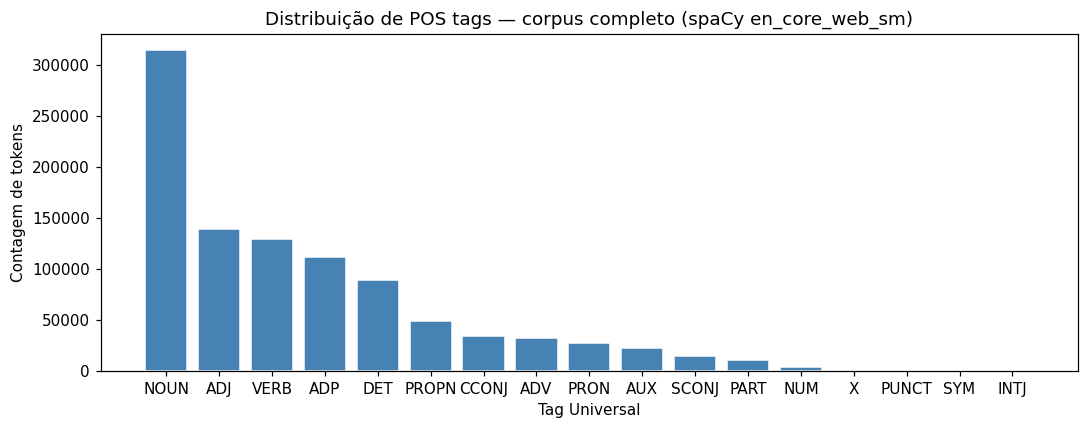


NOUN representa 32.0% de todos os tokens alfa


In [267]:
pos_counts = Counter(
    token.pos_
    for doc in docs
    for token in doc
    if token.is_alpha
)
pos_df = (pd.DataFrame(pos_counts.items(), columns=['POS', 'Frequência'])
            .sort_values('Frequência', ascending=False)
            .reset_index(drop=True))

print(pos_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pos_df['POS'], pos_df['Frequência'], color='steelblue', edgecolor='white')
ax.set_title('Distribuição de POS tags — corpus completo (spaCy en_core_web_sm)')
ax.set_xlabel('Tag Universal'); ax.set_ylabel('Contagem de tokens')
plt.tight_layout()
plt.savefig('outputs/fig_pos_distribution.png', bbox_inches='tight')
plt.show()

noun_pct = pos_counts['NOUN'] / sum(pos_counts.values()) * 100
print(f'\nNOUN representa {noun_pct:.1f}% de todos os tokens alfa')


## 1.7 Análise de Impacto no Vocabulário


In [268]:
vocab_raw      = len({t for toks in df['tokens_raw']      for t in toks})
vocab_filtered = len({t for toks in df['tokens_filtered']  for t in toks})
vocab_stemmed  = len({t for toks in df['tokens_stemmed']   for t in toks})
vocab_lemma    = len({t for toks in df['tokens_lemma']     for t in toks})

summary = pd.DataFrame({
    'Etapa': [
        'Tokenização bruta (alpha, lower)',
        'Após remoção de stopwords',
        'Após stemming (Porter)',
        'Após lemmatização (spaCy)',
    ],
    'Tokens únicos': [vocab_raw, vocab_filtered, vocab_stemmed, vocab_lemma],
    'Redução vs bruto': [
        '—',
        f'{(1 - vocab_filtered/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_stemmed/vocab_raw)*100:.1f}%',
        f'{(1 - vocab_lemma/vocab_raw)*100:.1f}%',
    ],
})
print(summary.to_string(index=False))


                           Etapa  Tokens únicos Redução vs bruto
Tokenização bruta (alpha, lower)          21835                —
       Após remoção de stopwords          21645             0.9%
          Após stemming (Porter)          13701            37.3%
       Após lemmatização (spaCy)          18931            13.3%


### Interpretação

- **Stopwords** removem os termos de alta frequência e baixo conteúdo. A magnitude depende da fração de hápax (palavras que aparecem uma só vez), que não são afetados pela lista de stopwords.
- **Stemming (Porter)** produz a maior compressão de vocabulário, mas ao custo de legibilidade: raízes como *optim*, *regress* e *distribut* não são palavras interpretáveis. No topic modeling isso geraria tópicos difíceis de comunicar.
- **Lemmatização (spaCy)** oferece compressão moderada com preservação total da legibilidade. O lema *network* (de *networks*, *networking*) é imediatamente compreensível; o mesmo vale para *algorithm*, *learn*, *distribute*.

**Escolha consolidada:** `tokens_lemma` é a representação adotada nas fases 2–5 do pipeline.


## 1.8 Visualizações


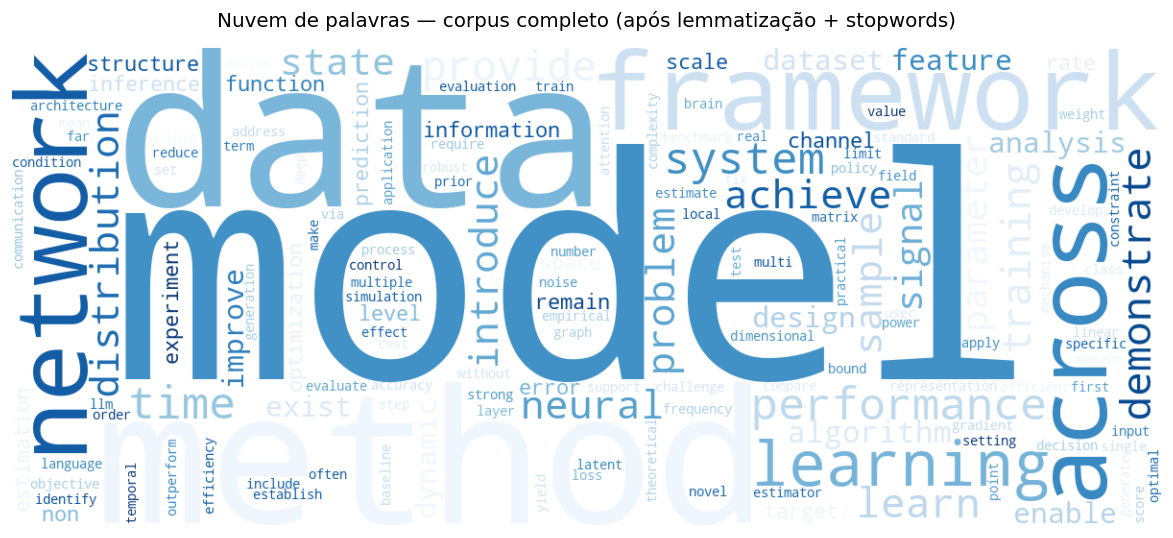

Stopwords de domínio ausentes da nuvem (amostra): ['paper', 'propose', 'result', 'approach', 'show']


In [269]:
all_lemmas = ' '.join(t for toks in df['tokens_lemma'] for t in toks)

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    max_words=150,
    colormap='Blues_r',
    collocations=False,
).generate(all_lemmas)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Nuvem de palavras — corpus completo (após lemmatização + stopwords)',
    pad=14, fontsize=13
)
plt.tight_layout()
plt.savefig('outputs/fig_wordcloud.png', bbox_inches='tight')
plt.show()

# Confirm domain stopwords are absent
absent = [t for t in ['paper', 'propose', 'result', 'approach', 'show']
          if t not in all_lemmas.split()[:5000]]
print('Stopwords de domínio ausentes da nuvem (amostra):', absent)


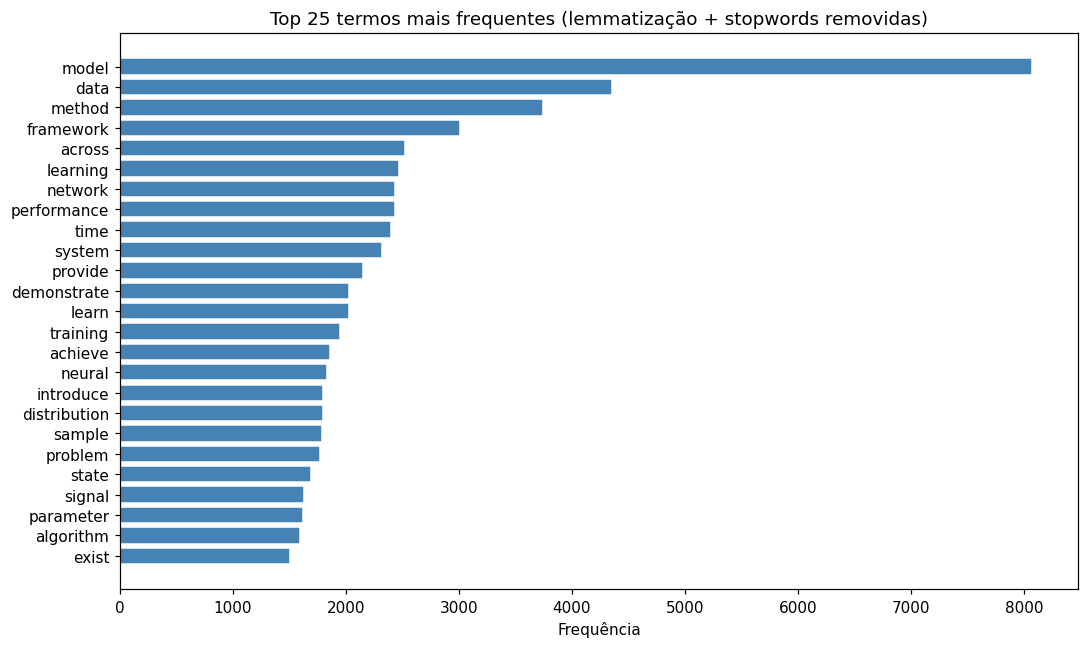

In [270]:
TOP_N = 25
counter = Counter(t for toks in df['tokens_lemma'] for t in toks)
terms, freqs = zip(*counter.most_common(TOP_N))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), freqs[::-1], color='steelblue', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(terms[::-1])
ax.set_title(f'Top {TOP_N} termos mais frequentes (lemmatização + stopwords removidas)')
ax.set_xlabel('Frequência')
plt.tight_layout()
plt.savefig('outputs/fig_top_terms.png', bbox_inches='tight')
plt.show()


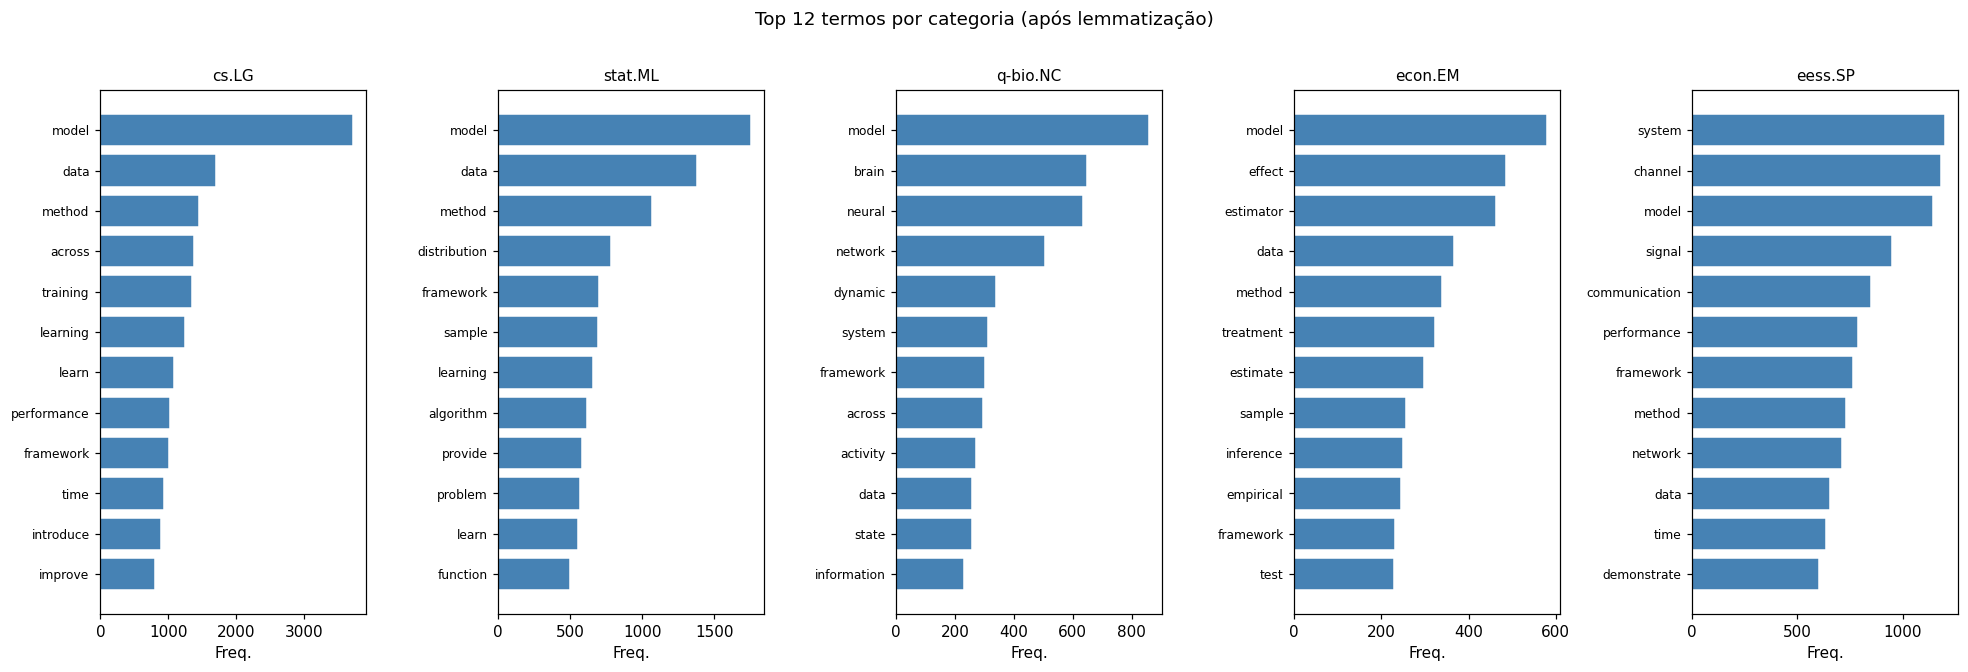

In [271]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAF7')

for ax, cat in zip(axes, CATEGORY_ORDER):
    sub = df[df['primary_category'] == cat]['tokens_lemma']
    cnt = Counter(t for toks in sub for t in toks)
    top = cnt.most_common(12)
    ts, fs = zip(*top)
    col = CATEGORY_COLORS[cat]
    ax.barh(range(len(ts)), list(reversed(fs)), color=col, edgecolor='white', alpha=0.87)
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels(list(reversed(ts)), fontsize=8)
    ax.set_title(cat, fontsize=10, color=col, fontweight='bold')
    ax.set_xlabel('Freq.')
    ax.set_facecolor('#FAFAF7')
    for _s in ['top', 'right']: ax.spines[_s].set_visible(False)

plt.suptitle('Top 12 termos por categoria (após lemmatização)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_top_terms_by_cat.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

## Saída da Fase 1

Salvamos o dataframe aumentado com `text_preprocessed` (lemas unidos por espaço)
e `tokens_lemma` (lista de tokens) para evitar re-executar o pipeline spaCy
nas fases seguintes.


In [272]:
df['text_preprocessed'] = df['tokens_lemma'].apply(lambda toks: ' '.join(toks))

cols_out = [
    'id', 'title', 'abstract', 'abstract_clean',
    'primary_category', 'authors', 'published',
    'tokens_lemma', 'text_preprocessed',
]
df[cols_out].to_parquet('data/corpus_preprocessed.parquet', index=False)
print('Salvo: data/corpus_preprocessed.parquet')
print(f'Shape: {df[cols_out].shape}')
print(f'Colunas: {list(df[cols_out].columns)}')


Salvo: data/corpus_preprocessed.parquet
Shape: (5400, 9)
Colunas: ['id', 'title', 'abstract', 'abstract_clean', 'primary_category', 'authors', 'published', 'tokens_lemma', 'text_preprocessed']


## Fase 2 — Representação Vetorial e Busca Textual (Requisito 2)

**Objetivo:** transformar o corpus pré-processado em representações numéricas para busca e análise.

**Técnicas:**
1. **Bag-of-Words (CountVectorizer)** — baseline de contagem sem ponderação de raridade.
2. **TF-IDF (TfidfVectorizer)** — pondera termos por raridade global; representação adotada para busca.
3. **N-gramas** — bigramas e trigramas revelam colocações técnicas compostas.
4. **Word2Vec (Gensim)** — exploratório/decorativo: embeddings de palavras para visualização apenas. **Não entra na busca nem na classificação** (limitação declarada na seção 2.3).
5. **Similaridade por cosseno** — métrica de distância no espaço TF-IDF.
6. **Motor de busca** — TF-IDF + cosseno, vetorizador fitado uma única vez no corpus.
7. **t-SNE dos documentos** — projeção 2D dos vetores TF-IDF, colorida por categoria.

In [273]:
# ── Fase 2: imports e carregamento ──────────────────────────────────
import joblib
import numpy as np
import scipy.sparse
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

df = pd.read_parquet('data/corpus_preprocessed.parquet')
corpus      = df['text_preprocessed'].tolist()
# Ensure token_lists is a list of plain Python lists of str (pyarrow may return
# Arrow arrays which Gensim's C extension does not handle efficiently)
token_lists = [list(map(str, toks)) for toks in df['tokens_lemma']]
labels      = df['primary_category'].tolist()

print(f'Corpus: {len(corpus)} documentos, {len(set(labels))} categorias')
print(f'Exemplo (texto pre-proc.): {corpus[0][:120]}')
print(f'Tokens no 1o doc: {token_lists[0][:10]}')

Corpus: 5400 documentos, 5 categorias
Exemplo (texto pre-proc.): deep learning face homogenization across modality lead transformers still challenge shallow linear model time series for
Tokens no 1o doc: ['deep', 'learning', 'face', 'homogenization', 'across', 'modality', 'lead', 'transformers', 'still', 'challenge']


## 2.1 Bag-of-Words e TF-IDF

**CountVectorizer (BoW)** conta ocorrências brutas de cada termo por documento. Simples e interpretável, mas insensível à raridade global: "model" e um termo técnico raro recebem o mesmo peso se ocorrem igualmente no documento.

**TfidfVectorizer** pondera as contagens pelo IDF — termos muito frequentes no corpus inteiro são downweighted; termos raros e específicos ganham peso maior, tornando a representação mais discriminativa para busca e classificação.

Parâmetros:
- `min_df=3`: descarta termos que aparecem em menos de 3 documentos (hápax irrelevantes).
- `max_df=0.90`: descarta termos presentes em mais de 90% dos documentos (sem poder discriminativo).
- `max_features=20_000`: limite de vocabulário para eficiência computacional.
- `sublinear_tf=True`: aplica `1 + log(tf)`, comprimindo o efeito de repetições excessivas em um mesmo abstract.

O `TfidfVectorizer` é **fitado uma única vez** no corpus completo e persistido em disco — reutilizado no motor de busca e nas fases seguintes, sem jamais refitar por consulta.

In [274]:
# ── 2.1 BoW e TF-IDF ────────────────────────────────────────────────
bow = CountVectorizer(min_df=3, max_df=0.90, max_features=20_000)
bow_matrix = bow.fit_transform(corpus)
bow_density = bow_matrix.nnz / np.prod(bow_matrix.shape)
print(f'BoW    shape={bow_matrix.shape}  sparsidade={1-bow_density:.4f}')

tfidf = TfidfVectorizer(min_df=3, max_df=0.90, max_features=20_000, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(corpus)
tfidf_density = tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)
print(f'TF-IDF shape={tfidf_matrix.shape}  sparsidade={1-tfidf_density:.4f}')

feature_names = np.array(tfidf.get_feature_names_out())
idf_scores    = tfidf.idf_
top20_idx     = np.argsort(idf_scores)[::-1][:20]
print('\nTop 20 termos com maior IDF (mais raros no corpus):')
for term, score in zip(feature_names[top20_idx], idf_scores[top20_idx]):
    print(f'  {term:30s}  IDF={score:.3f}')

joblib.dump(tfidf, 'outputs/tfidf_vectorizer.joblib')
scipy.sparse.save_npz('outputs/tfidf_matrix.npz', tfidf_matrix)
print('\nArtefatos salvos: outputs/tfidf_vectorizer.joblib, outputs/tfidf_matrix.npz')

BoW    shape=(5400, 7634)  sparsidade=0.9890
TF-IDF shape=(5400, 7634)  sparsidade=0.9890

Top 20 termos com maior IDF (mais raros no corpus):
  ablate                          IDF=8.208
  abm                             IDF=8.208
  xilinx                          IDF=8.208
  xr                              IDF=8.208
  yoshida                         IDF=8.208
  hvp                             IDF=8.208
  hydrodynamic                    IDF=8.208
  hyperdimensional                IDF=8.208
  hypergradient                   IDF=8.208
  hypergraphs                     IDF=8.208
  reshapes                        IDF=8.208
  actuator                        IDF=8.208
  acyclicity                      IDF=8.208
  adaption                        IDF=8.208
  addressable                     IDF=8.208
  ade                             IDF=8.208
  willie                          IDF=8.208
  willingness                     IDF=8.208
  wilson                          IDF=8.208
  overwhelm          

## 2.2 N-gramas: Bigramas e Trigramas

Unigramas perdem colocações técnicas importantes: "neural network" como bigrama é muito mais informativo do que "neural" e "network" isolados. Bigramas e trigramas expõem os jargões compostos que definem cada área e revelam diferenças terminológicas entre disciplinas.

Usamos um `CountVectorizer` dedicado com `ngram_range=(2, 3)` sobre o corpus já pré-processado (lemmatizado, sem stopwords). A frequência total de cada n-grama é obtida somando as colunas da matriz esparsa.

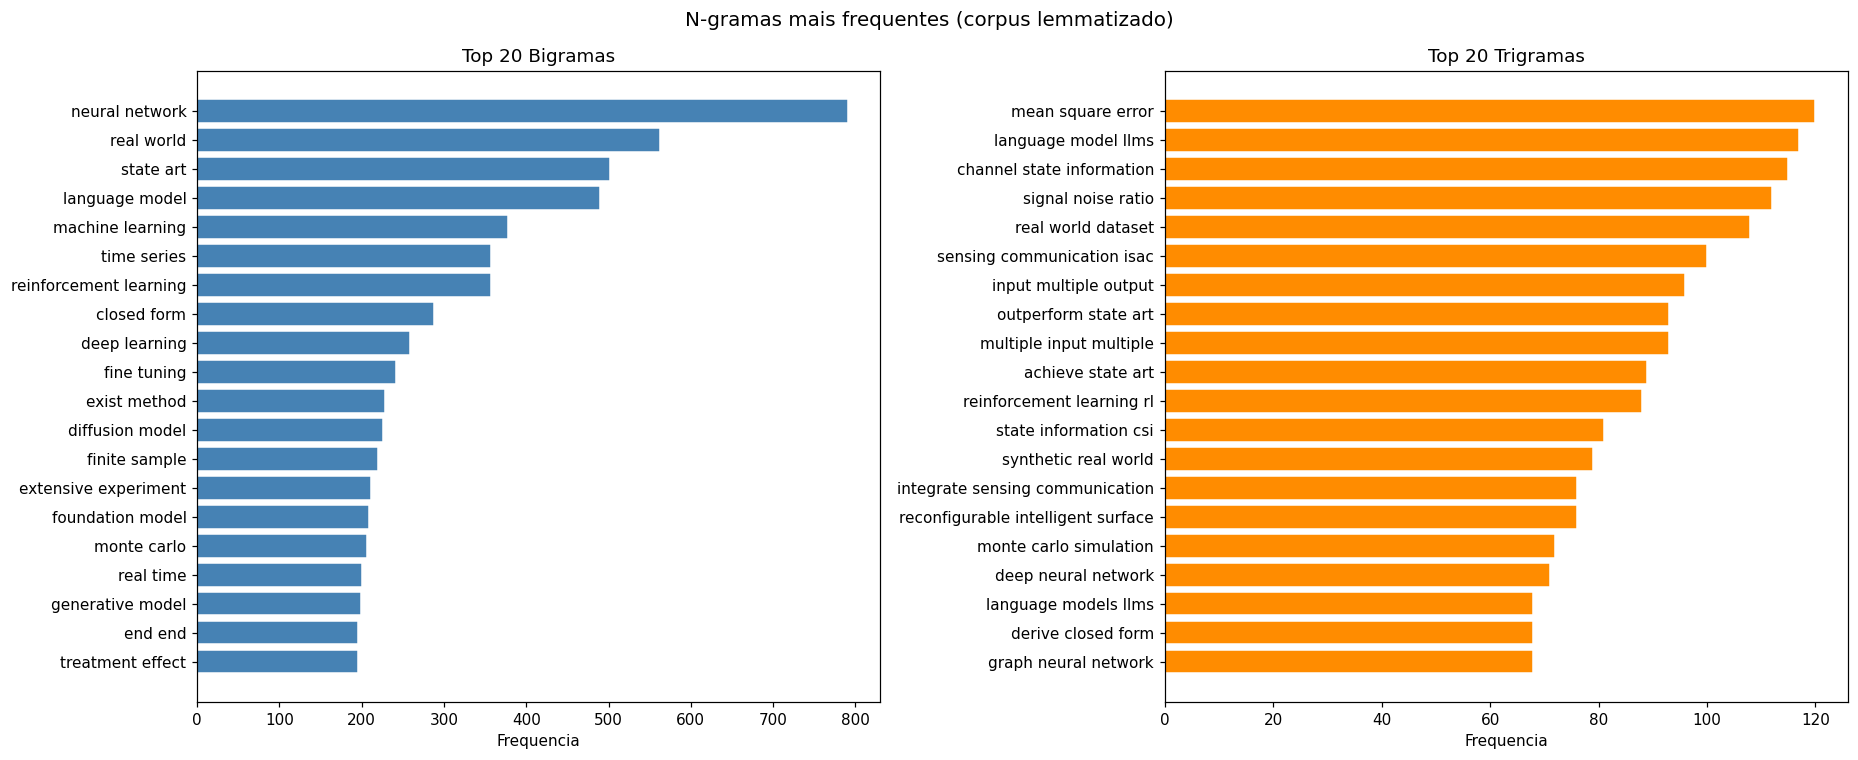

In [275]:
# ── 2.2 N-gramas ────────────────────────────────────────────────────
ng_vec    = CountVectorizer(ngram_range=(2, 3), min_df=5, max_features=60_000)
ng_matrix = ng_vec.fit_transform(corpus)

ng_names  = ng_vec.get_feature_names_out()
ng_counts = np.asarray(ng_matrix.sum(axis=0)).flatten()
ng_df = (pd.DataFrame({'ngram': ng_names, 'count': ng_counts})
           .sort_values('count', ascending=False)
           .reset_index(drop=True))

bigrams  = ng_df[ng_df['ngram'].str.count(' ') == 1].head(20)
trigrams = ng_df[ng_df['ngram'].str.count(' ') == 2].head(20)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].barh(range(len(bigrams)), bigrams['count'].values[::-1],
             color='steelblue', edgecolor='white')
axes[0].set_yticks(range(len(bigrams)))
axes[0].set_yticklabels(bigrams['ngram'].values[::-1])
axes[0].set_title('Top 20 Bigramas', fontsize=12)
axes[0].set_xlabel('Frequencia')

axes[1].barh(range(len(trigrams)), trigrams['count'].values[::-1],
             color='darkorange', edgecolor='white')
axes[1].set_yticks(range(len(trigrams)))
axes[1].set_yticklabels(trigrams['ngram'].values[::-1])
axes[1].set_title('Top 20 Trigramas', fontsize=12)
axes[1].set_xlabel('Frequencia')

plt.suptitle('N-gramas mais frequentes (corpus lemmatizado)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig_ngrams.png', bbox_inches='tight')
plt.show()

## 2.3 Word2Vec — Embeddings de Palavras (Exploratório)

> **Nota de limitação (PROJECT_PLAN.md — Decisão Travada):** o corpus tem ~5 400 abstracts e ~630 000 tokens pós-pré-processamento. Word2Vec aprende relações semânticas por co-ocorrência local e produz embeddings robustos com corpora da ordem de centenas de milhões de tokens (Google News, Wikipedia). Com corpus pequeno, vizinhanças no espaço de embedding são instáveis e não capturam relações semânticas confiáveis.
>
> **Consequência de design:** Word2Vec é mantido aqui **exclusivamente como exploração visual** (demo `most_similar` + t-SNE de palavras). O motor de busca usa **TF-IDF + cosseno**; a classificação usará **features TF-IDF**. Word2Vec não entra em nenhum componente funcional do pipeline.

Configuração:
- `sg=1` (Skip-gram): aprende melhor com termos raros — adequado para vocabulário técnico.
- `vector_size=100`, `window=5`, `min_count=5`.
- `seed=42`: fixa a inicialização aleatória dos pesos. Com múltiplos workers a ordem de atualização dos gradientes depende do escalonamento de threads e não é determinística, mas resultados práticos são estáveis entre execuções com este seed.

In [276]:
# ── 2.3 Word2Vec: treino ────────────────────────────────────────────
w2v = Word2Vec(
    sentences=token_lists,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    seed=42,
    workers=1,
    epochs=10,
)
print(f'Word2Vec treinado  vocabulario: {len(w2v.wv):,} termos\n')

demo_terms = ['neural', 'regression', 'bayesian', 'signal', 'spike', 'optimization']
for term in demo_terms:
    if term in w2v.wv:
        neighbors = w2v.wv.most_similar(term, topn=6)
        nb_str = ', '.join(f'{w}({s:.2f})' for w, s in neighbors)
        print(f'{term:15s}  {nb_str}')
    else:
        print(f'{term:15s}  [fora do vocabulario — min_count=5]')

Word2Vec treinado  vocabulario: 7,095 termos

neural           arnold(0.68), prototypical(0.67), anns(0.66), rnns(0.66), heaviside(0.64), isomorphism(0.64)
regression       rd(0.67), svm(0.66), cox(0.64), huber(0.64), heteroskedastic(0.64), nonparametric(0.64)
bayesian         abi(0.64), amortized(0.64), tpnn(0.62), npe(0.60), frequentist(0.59), trees(0.59)
signal           snrs(0.59), rsrp(0.59), scnr(0.57), undesired(0.56), iq(0.54), amplifier(0.53)
spike            snns(0.68), postsynaptic(0.66), rhythmic(0.64), synapsis(0.63), burst(0.63), excitatory(0.63)
optimization     ao(0.67), optimisation(0.65), maximisation(0.64), formulated(0.62), obo(0.60), subproblem(0.60)


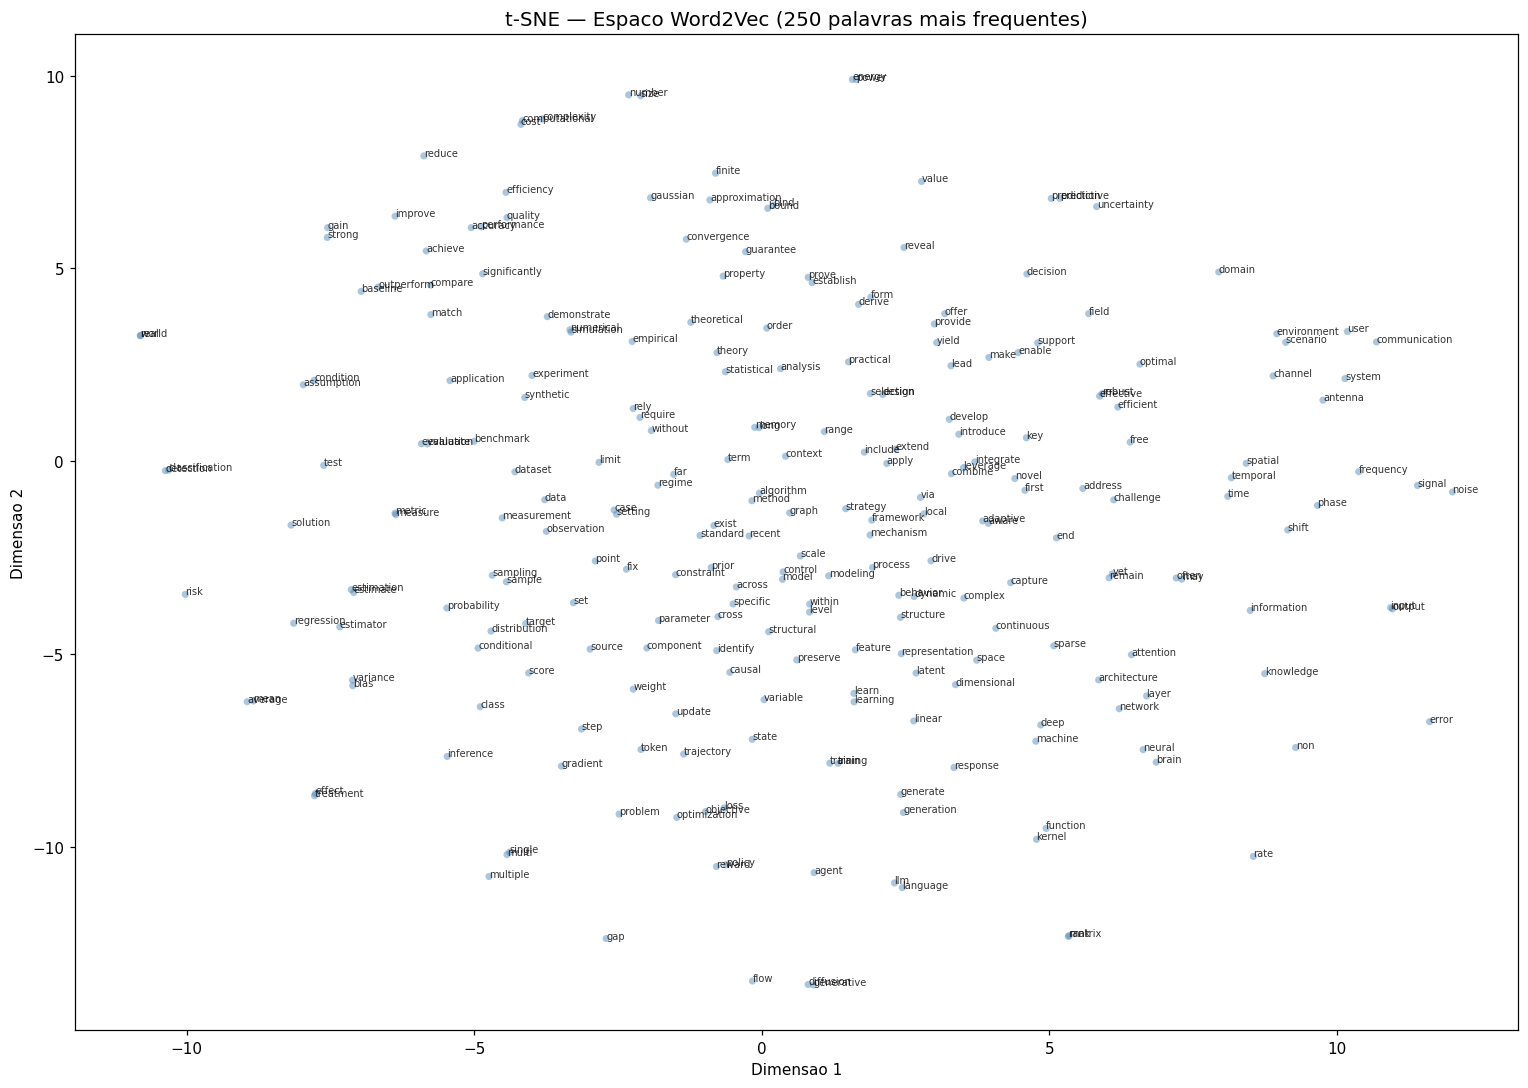

In [277]:
# ── Word2Vec: t-SNE das top-250 palavras ────────────────────────────
vocab_counts = Counter(t for toks in token_lists for t in toks)
top_words    = [w for w, _ in vocab_counts.most_common(300) if w in w2v.wv][:250]
vecs_w2v     = np.array([w2v.wv[w] for w in top_words])

tsne_w2v   = TSNE(n_components=2, random_state=42, perplexity=30,
                  max_iter=1000, learning_rate='auto', init='pca')
coords_w2v = tsne_w2v.fit_transform(vecs_w2v)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords_w2v[:, 0], coords_w2v[:, 1],
           c='steelblue', alpha=0.45, s=22, edgecolors='none')
for i, w in enumerate(top_words):
    ax.annotate(w, (coords_w2v[i, 0], coords_w2v[i, 1]), fontsize=6.5, alpha=0.80)
ax.set_title('t-SNE — Espaco Word2Vec (250 palavras mais frequentes)', fontsize=13)
ax.set_xlabel('Dimensao 1'); ax.set_ylabel('Dimensao 2')
plt.tight_layout()
plt.savefig('outputs/fig_w2v_tsne.png', bbox_inches='tight')
plt.show()

## 2.4 Similaridade por Cosseno

A similaridade por cosseno mede o ângulo entre dois vetores TF-IDF no espaço de alta dimensão, ignorando a magnitude (normaliza pelo comprimento do vetor). Documentos sobre os mesmos temas tendem a usar as mesmas palavras com pesos similares — ângulo pequeno, similaridade próxima a 1.

A preferência sobre distância euclidiana se justifica porque documentos mais longos têm vetores de maior norma; o cosseno normaliza isso implicitamente, tornando-o invariante ao comprimento do abstract.

**Demo empírico:** comparamos a distribuição de similaridade para pares dentro de `cs.LG` contra pares entre `cs.LG` e `econ.EM` — categorias metodologicamente distantes. A separação das distribuições indica que o espaço TF-IDF capturou diferenças temáticas reais.

Cosseno medio cs.LG x cs.LG   : 0.0436  (s=0.0235)
Cosseno medio cs.LG x econ.EM : 0.0280  (s=0.0176)


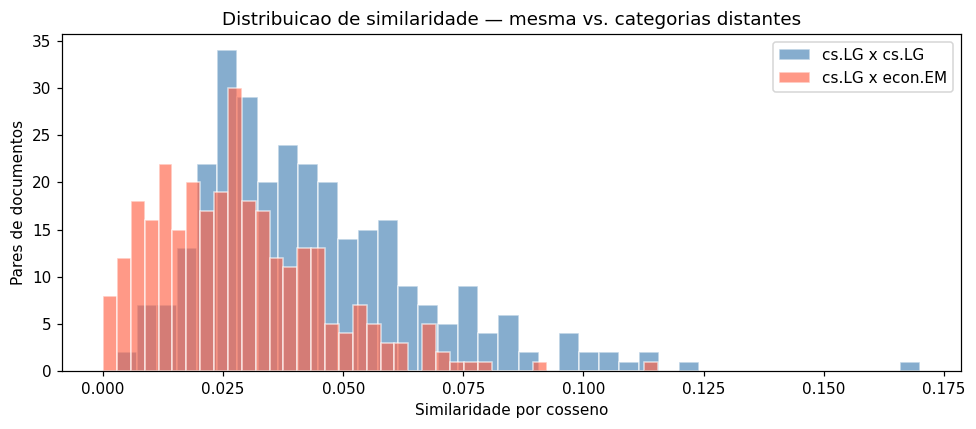

In [278]:
# ── 2.4 Similaridade por Cosseno ────────────────────────────────────
rng      = np.random.default_rng(42)
lbl_arr  = np.array(labels)
cs_idx   = np.where(lbl_arr == 'cs.LG')[0]
econ_idx = np.where(lbl_arr == 'econ.EM')[0]

same_pairs = [(int(rng.choice(cs_idx)),   int(rng.choice(cs_idx)))   for _ in range(300)]
diff_pairs = [(int(rng.choice(cs_idx)),   int(rng.choice(econ_idx))) for _ in range(300)]

def _cosine_pairs(pairs, mat):
    return [float(cosine_similarity(mat[i], mat[j])[0, 0])
            for i, j in pairs if i != j]

same_sims = _cosine_pairs(same_pairs, tfidf_matrix)
diff_sims = _cosine_pairs(diff_pairs, tfidf_matrix)

print(f'Cosseno medio cs.LG x cs.LG   : {np.mean(same_sims):.4f}  (s={np.std(same_sims):.4f})')
print(f'Cosseno medio cs.LG x econ.EM : {np.mean(diff_sims):.4f}  (s={np.std(diff_sims):.4f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(same_sims, bins=40, alpha=0.65, color='steelblue',
        edgecolor='white', label='cs.LG x cs.LG')
ax.hist(diff_sims, bins=40, alpha=0.65, color='tomato',
        edgecolor='white', label='cs.LG x econ.EM')
ax.set_xlabel('Similaridade por cosseno')
ax.set_ylabel('Pares de documentos')
ax.set_title('Distribuicao de similaridade — mesma vs. categorias distantes')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/fig_cosine_dist.png', bbox_inches='tight')
plt.show()

## 2.5 Motor de Busca Textual (TF-IDF + Cosseno)

O motor transforma uma consulta em linguagem livre no mesmo espaço vetorial TF-IDF do corpus e rankeia todos os documentos por similaridade de cosseno.

**Pipeline da consulta:**
1. A consulta é vetorizada com `tfidf.transform()` — o mesmo objeto fitado no corpus, **sem refitar**.
2. O vetor de consulta (1 × vocab) é comparado contra `tfidf_matrix` (5 400 × vocab) via `cosine_similarity`.
3. Os top-k documentos por score são retornados com `id`, `title`, `primary_category` e `score`.

**Por que não Word2Vec?** Média de vetores de palavras perde informação de frequência local e é instável em corpus pequeno. TF-IDF + cosseno é robusto, totalmente interpretável e demonstra performance competitiva em domínios com vocabulário técnico estável.

*Nota:* o vocabulário do vetorizador contém lemas. Termos inflectados na consulta ("networks", "forecasting") que não estão no vocabulário são ignorados silenciosamente — os termos-raiz ("neural", "time", "series", "bayesian") são suficientes para recuperação eficaz.

In [279]:
# ── 2.5 Motor de Busca ───────────────────────────────────────────────

def search(query: str, k: int = 5) -> pd.DataFrame:
    """Vetoriza a consulta com o TfidfVectorizer fitado e retorna top-k docs."""
    q_vec  = tfidf.transform([query])
    sims   = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_k  = np.argsort(sims)[::-1][:k]
    result = df.iloc[top_k][['id', 'title', 'primary_category']].copy()
    result['score'] = sims[top_k].round(4)
    result.index = range(1, k + 1)
    return result

print('Funcao search(query, k) definida. TfidfVectorizer fitado no corpus completo.')

Funcao search(query, k) definida. TfidfVectorizer fitado no corpus completo.


In [280]:
q1 = 'neural networks for time series forecasting'
print(f'Consulta 1: "{q1}"\n')
print(search(q1, k=5).to_string())

Consulta 1: "neural networks for time series forecasting"

           id                                                                                                        title primary_category   score
1  2605.00015            TimeRFT: Stimulating Generalizable Time Series Forecasting for TSFMs via Reinforcement Finetuning          eess.SP  0.2667
2  2605.01608  Why Model Selection Fails in Time Series Forecasting: An Empirical Study of Instability Across Data Regimes          eess.SP  0.2563
3  2605.14422      What if Tomorrow is the World Cup Final? Counterfactual Time Series Forecasting with Textual Conditions            cs.LG  0.2498
4  2605.10292                              LeapTS: Rethinking Time Series Forecasting as Adaptive Multi-Horizon Scheduling            cs.LG  0.2486
5  2508.20206                Filter then Attend: Improving attention-based Time Series Forecasting with Spectral Filtering            cs.LG  0.2442


In [281]:
q2 = 'bayesian uncertainty estimation'
print(f'Consulta 2: "{q2}"\n')
print(search(q2, k=5).to_string())

Consulta 2: "bayesian uncertainty estimation"

           id                                                                                                          title primary_category   score
1  2604.26673                                              Laplace Approximation for Bayesian Tensor Network Kernel Machines          stat.ML  0.2561
2  2604.12434  A Bayesian Perspective on the Role of Epistemic Uncertainty for Delayed Generalization in In-Context Learning          stat.ML  0.2531
3  2603.03035                                                                         Generalized Bayes for Causal Inference          stat.ML  0.2487
4  2605.10378                                        Uncertainty in Physics and AI: Taxonomy, Quantification, and Validation          stat.ML  0.2481
5  2501.04272                                     On weight and variance uncertainty in neural networks for regression tasks          stat.ML  0.2183


In [282]:
q3 = 'graph models of brain connectivity'
print(f'Consulta 3: "{q3}"\n')
print(search(q3, k=5).to_string())

Consulta 3: "graph models of brain connectivity"

           id                                                                                                                                  title primary_category   score
1  2505.24125                                                          Weak structural connectivity nonlinearly underlying human cognitive abilities         q-bio.NC  0.2476
2  2603.22296                                                                                                      Sketching a Space of Brain States         q-bio.NC  0.1937
3  2509.09696  DCHO: A Decomposition-Composition Framework for Predicting Higher-Order Brain Connectivity to Enhance Diverse Downstream Applications         q-bio.NC  0.1914
4  2508.16414            NeuroKoop: Neural Koopman Fusion of Structural-Functional Connectomes for Identifying Prenatal Drug Exposure in Adolescents         q-bio.NC  0.1878
5  2510.03306                                                                   

### Avaliação das Consultas

**Consulta 1 — "neural networks for time series forecasting"**
Esperamos resultados predominantemente de `cs.LG` e `stat.ML`, com foco em arquiteturas sequenciais (RNN, LSTM, Transformer) aplicadas a séries temporais. A presença de `eess.SP` é plausível — processamento de sinais trabalha com dados sequenciais em contextos diferentes (áudio, radar). Um resultado de `econ.EM` indicaria um abstract econométrico com linguagem próxima à de deep learning.

**Consulta 2 — "bayesian uncertainty estimation"**
`stat.ML` deve dominar (inferência bayesiana, variational inference, processos gaussianos). `cs.LG` pode aparecer com Bayesian deep learning. `econ.EM` tem tradição bayesiana forte em econometria — sua presença seria coerente e revela a circulação desse ferramental entre domínios.

**Consulta 3 — "graph models of brain connectivity"**
`q-bio.NC` deve dominar (modelos de conectoma, redes de coativação, dinâmica neural em grafos). `cs.LG` pode aparecer com Graph Neural Networks — este caso testa a capacidade do motor de distinguir neurociência computacional de GNNs para fins gerais. Resultados mistos aqui revelam o vocabulário compartilhado entre as duas áreas.

## 2.6 t-SNE dos Vetores TF-IDF por Documento

Projeção t-SNE do espaço TF-IDF (até 20 000 dimensões) para 2D. O t-SNE preserva estrutura local: documentos vizinhos no espaço de alta dimensão tendem a ficar próximos na projeção.

**Interpretação esperada:** categorias com vocabulário muito distinto (`q-bio.NC`, `econ.EM`) devem formar aglomerados mais coesos. `cs.LG` e `stat.ML` provavelmente se sobreporão — compartilham extenso vocabulário metodológico. Zonas de sobreposição são achados analíticos: indicam onde o corpus reflete a circulação de métodos entre disciplinas — narrativa central do projeto.

**Implementação:** `TruncatedSVD` de 20 000 → 50 dimensões (reduz ruído e acelera o t-SNE preservando variância dominante), seguido de t-SNE de 50 → 2 dimensões. Amostra de 2 000 documentos para viabilidade computacional.

TruncatedSVD: variancia explicada (50 comp.) = 0.127


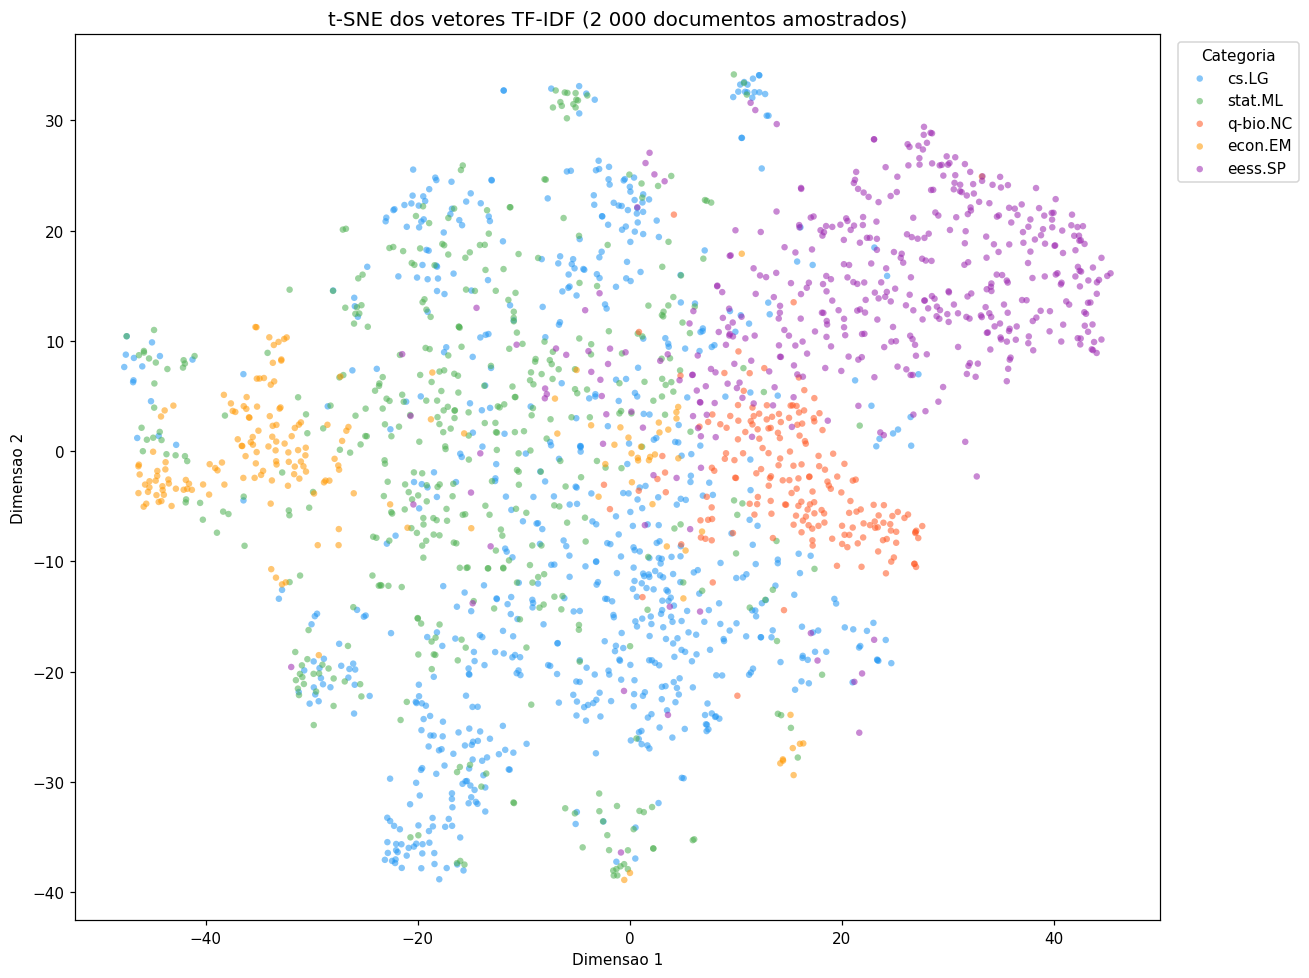

In [283]:
# ── 2.6 t-SNE dos vetores TF-IDF ────────────────────────────────────
N_SAMPLE   = 2_000
rng2       = np.random.default_rng(42)
sample_idx = rng2.choice(len(df), size=N_SAMPLE, replace=False)

X_sample = tfidf_matrix[sample_idx]
y_sample = [labels[i] for i in sample_idx]

svd  = TruncatedSVD(n_components=50, random_state=42)
X_50 = svd.fit_transform(X_sample)
print(f'TruncatedSVD: variância explicada (50 comp.) = {svd.explained_variance_ratio_.sum():.3f}')

tsne_doc = TSNE(n_components=2, random_state=42, perplexity=40,
                max_iter=1000, learning_rate='auto', init='pca')
X_2d = tsne_doc.fit_transform(X_50)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#FAFAF7')
ax.set_facecolor('#FAFAF7')
for cat in CATEGORY_ORDER:
    mask = np.array([c == cat for c in y_sample])
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CATEGORY_COLORS[cat], label=cat, alpha=0.55, s=18, edgecolors='none')
ax.set_title('t-SNE dos vetores TF-IDF (2 000 documentos amostrados)', fontsize=13)
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.8)
ax.set_xlabel('Dimensão 1'); ax.set_ylabel('Dimensão 2')
for _s in ['top', 'right']: ax.spines[_s].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/fig_tsne_tfidf.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

## Saída da Fase 2

Artefatos persistidos em `outputs/`:

| Arquivo | Conteúdo |
|---|---|
| `tfidf_vectorizer.joblib` | `TfidfVectorizer` fitado no corpus completo |
| `tfidf_matrix.npz` | Matriz TF-IDF esparsa (5 400 × vocab) |
| `fig_ngrams.png` | Top 20 bigramas e trigramas |
| `fig_w2v_tsne.png` | t-SNE do espaço Word2Vec (250 palavras) |
| `fig_cosine_dist.png` | Distribuição de similaridade por cosseno |
| `fig_tsne_tfidf.png` | t-SNE dos documentos TF-IDF por categoria |

**Motor de busca** (`search(query, k)`) disponível no namespace do notebook.

**Nota para Fase 3:** na classificação supervisionada, o `TfidfVectorizer` será **refitado apenas no conjunto de treino** para evitar vazamento de dados (data leakage). O artefato salvo aqui serve exclusivamente para busca e visualizações desta fase.

## Fase 3 — Modelagem de Tópicos e Classificação Supervisionada (Requisito 3)

### Por que não há análise de sentimento?

Abstracts científicos operam em um registro descritivo-argumentativo estritamente neutro: afirmam resultados, descrevem métodos e enumeram contribuições. Não há polaridade emocional mensurável — não existe "abstract positivo" ou "abstract negativo" em qualquer sentido linguístico coerente. Aplicar um léxico de sentimento (VADER, TextBlob) ou um modelo de polaridade produziria scores arbitrários sem validade científica, constituindo um artefato de metodologia inadequada, não um achado. O Requisito 3 é integralmente atendido pelas duas frentes abaixo.

---

**Parte A — Modelagem de Tópicos (não supervisionado):** LDA e NMF revelam estrutura temática latente sem usar os rótulos de categoria.

**Parte B — Classificação Supervisionada:** Naive Bayes, SVM e Regressão Logística predizem a categoria disciplinar a partir de vetores TF-IDF, com tratamento explícito do desbalanceamento.

In [284]:
# ── Fase 3: imports ──────────────────────────────────────────────────
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import sklearn.metrics as skm
from imblearn.over_sampling import SMOTE

N_TOPICS = 10   # inside 8-12 range; balances granularity and interpretability
CATS     = ['cs.LG', 'stat.ML', 'q-bio.NC', 'econ.EM', 'eess.SP']
print('Imports OK')

Imports OK


## 3.1 Modelagem de Tópicos

**LDA (Latent Dirichlet Allocation):** modelo probabilístico generativo. Cada documento é uma mistura de tópicos; cada tópico é uma distribuição sobre palavras. Requer entrada de contagens (BoW) — LDA pressupõe dados discretos de Poisson/multinomial. Parâmetros: `n_components=10`, `learning_method='batch'` (EM exato), `max_iter=50`, `random_state=42`.

**NMF (Non-negative Matrix Factorization):** fatoração matricial determinística. Decompõe a matriz TF-IDF em dois fatores não-negativos: documento–tópico e tópico–termo. Não é um modelo probabilístico — impõe não-negatividade, produzindo tópicos tipicamente mais esparsos e menos sobrepostos que LDA. Parâmetros: `n_components=10`, `init='nndsvda'` (inicialização determinística baseada em SVD), `max_iter=500`, `random_state=42`.

**k = 10 tópicos:** com 5 categorias que compartilham métodos, espera-se mais de 5 tópicos — sub-comunidades como deep learning, reinforcement learning e inferência bayesiana coexistem dentro de `cs.LG` e `stat.ML`. Dez tópicos oferece granularidade suficiente sem fragmentação excessiva.

In [285]:
# ── 3.1a LDA (usa bow_matrix da Fase 2) ──────────────────────────────
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=50,
    learning_method='batch',
    random_state=42,
)
lda.fit(bow_matrix)
print(f'LDA ajustado. Log-likelihood no corpus: {lda.score(bow_matrix):.0f}')

bow_fn = np.array(bow.get_feature_names_out())

def show_topics(components, feature_names, n=12):
    rows = {}
    for i, comp in enumerate(components):
        top_idx = np.argsort(comp)[::-1][:n]
        rows[f'T{i+1:02d}'] = [feature_names[j] for j in top_idx]
    return pd.DataFrame(rows).T

lda_top = show_topics(lda.components_, bow_fn)
print(f'\nLDA — top 12 termos por topico:')
print(lda_top.to_string())

LDA ajustado. Log-likelihood no corpus: -4530395

LDA — top 12 termos por topico:
            0             1              2             3            4              5            6            7            8            9               10            11
T01      model  distribution          space        neural       method      diffusion         flow      dynamic        learn    framework           state          time
T02  algorithm       problem          bound      function       sample           rate  theoretical      optimal    establish  convergence         provide     guarantee
T03       time         model         system        across  forecasting          agent         real       series    benchmark     temporal        forecast          long
T04    network        neural          brain        system      dynamic          model     activity        human       neuron     response     information         state
T05    channel        system  communication        signal         user      fr

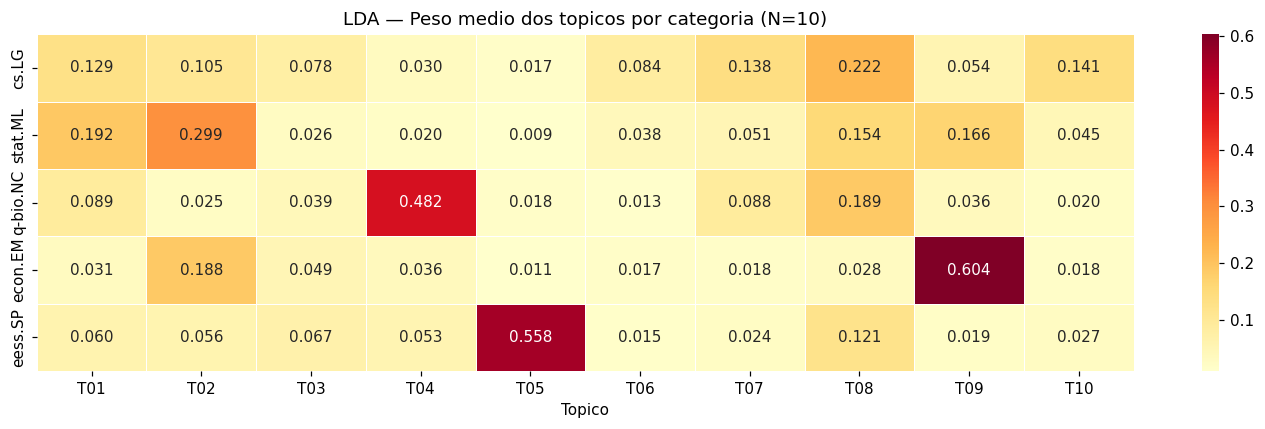

In [286]:
# ── LDA: distribuição média de tópicos por categoria ─────────────────
doc_topic_lda = lda.transform(bow_matrix)

cat_lda = (pd.DataFrame(doc_topic_lda,
                         columns=[f'T{i+1:02d}' for i in range(N_TOPICS)])
             .assign(category=labels)
             .groupby('category')
             .mean()
             .loc[CATS])

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#FAFAF7')
sns.heatmap(cat_lda, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.4, linecolor='#e0e0e0', ax=ax)
ax.set_title('LDA — Peso médio dos tópicos por categoria (N=10)', fontsize=12)
ax.set_ylabel(''); ax.set_xlabel('Tópico')
plt.tight_layout()
plt.savefig('outputs/fig_lda_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### NMF sobre TF-IDF

NMF recebe a matriz TF-IDF (floats não-negativos) — diferente do LDA que requer contagens inteiras. A inicialização `init='nndsvda'` é baseada em SVD truncado, tornando o resultado determinístico sem depender do `random_state` para a inicialização dos fatores (o seed é usado apenas para desempate).

In [287]:
# ── 3.1b NMF (usa tfidf_matrix da Fase 2) ────────────────────────────
nmf = NMF(
    n_components=N_TOPICS,
    init='nndsvda',
    max_iter=500,
    random_state=42,
)
nmf.fit(tfidf_matrix)
print(f'NMF ajustado. Erro de reconstrucao: {nmf.reconstruction_err_:.4f}')

tfidf_fn = np.array(tfidf.get_feature_names_out())
nmf_top = show_topics(nmf.components_, tfidf_fn)
print(f'\nNMF — top 12 termos por topico:')
print(nmf_top.to_string())

NMF ajustado. Erro de reconstrucao: 70.7560

NMF — top 12 termos por topico:
            0               1              2             3          4           5           6             7            8               9         10           11
T01       data         dataset           real        method      model  prediction    learning         world  performance     demonstrate  accuracy  uncertainty
T02    channel   communication         system       antenna       user    wireless      signal     frequency        power         sensing       ris     multiple
T03      bound       algorithm           rate   convergence    optimal   establish   guarantee          bind  theoretical         problem  function       sample
T04     policy          reward  reinforcement            rl      agent    learning      action  optimization      offline       algorithm     state        learn
T05    network          neural        dynamic  architecture       deep        time       layer      equation     opera

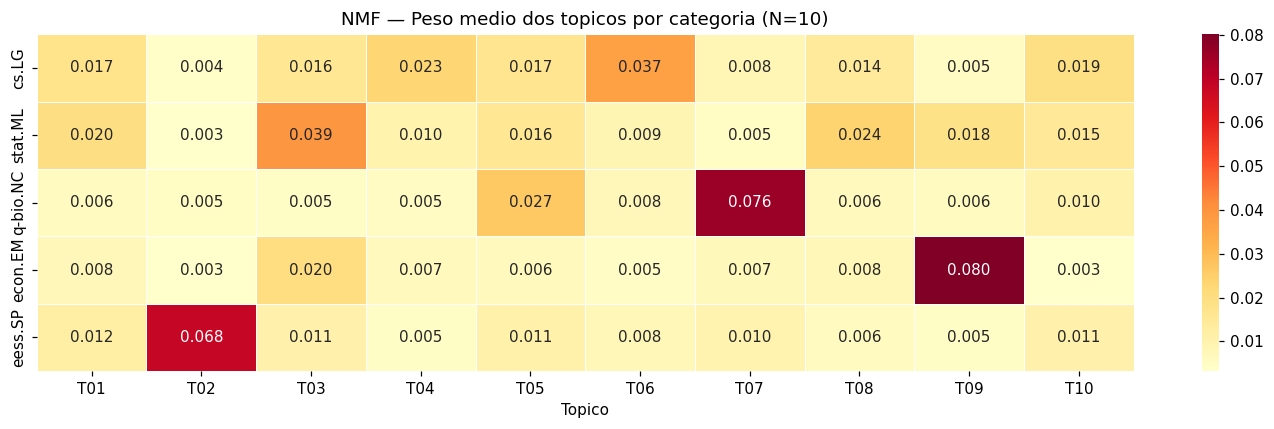

In [288]:
# ── NMF: distribuição média de tópicos por categoria ─────────────────
doc_topic_nmf = nmf.transform(tfidf_matrix)

cat_nmf = (pd.DataFrame(doc_topic_nmf,
                         columns=[f'T{i+1:02d}' for i in range(N_TOPICS)])
             .assign(category=labels)
             .groupby('category')
             .mean()
             .loc[CATS])

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#FAFAF7')
sns.heatmap(cat_nmf, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.4, linecolor='#e0e0e0', ax=ax)
ax.set_title('NMF — Peso médio dos tópicos por categoria (N=10)', fontsize=12)
ax.set_ylabel(''); ax.set_xlabel('Tópico')
plt.tight_layout()
plt.savefig('outputs/fig_nmf_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### Tópicos vs. Categorias — os Tópicos Não Precisam Coincidir com as Categorias

Com 10 tópicos e 5 categorias, é esperado que cada categoria mapeie em **mais de um tópico** — e que **alguns tópicos sejam compartilhados** entre categorias. Isso é um achado analítico, não um erro de modelagem:

1. **Categorias com múltiplos tópicos:** `cs.LG` abrange deep learning, reinforcement learning, teoria e aplicações — sub-comunidades metodológicas distintas que o modelo captura separadamente.
2. **Tópicos metodológicos transversais:** inferência bayesiana, otimização estocástica e redes de grafos aparecem em `cs.LG`, `stat.ML` e `econ.EM` simultaneamente. Este é o núcleo da narrativa do projeto: **o ferramental circula entre disciplinas**.
3. **Tópicos domínio-específicos:** `q-bio.NC` e `eess.SP` devem gerar tópicos próprios (neurônios, sinal, canal) bem separados dos demais.

Forçar 5 tópicos para casar com as categorias produziria um resultado artificialmente limpo e menos informativo — a granularidade extra de 10 tópicos revela onde as fronteiras disciplinares são porosas.

## 3.2 Classificação Supervisionada

### Prevenção de Vazamento de Dados (data leakage)

O `TfidfVectorizer` da Fase 2 foi ajustado no corpus **completo** — reutilizá-lo na classificação introduziria leakage: os pesos IDF incluem informação dos documentos de teste. Para o pipeline supervisionado, ajustamos um **novo vetorizador exclusivamente no `X_train`** e usamos `transform()` no `X_test`. Os parâmetros são idênticos aos da Fase 2 (mesma representação, sem contaminação).

### Estratégia de split

80% treino / 20% teste, estratificado por `primary_category`, `random_state=42`. O split estratificado preserva a distribuição de classes em ambos os conjuntos — essencial com dados desbalanceados.

### Tratamento do desbalanceamento

Duas abordagens testadas e comparadas:
- **`class_weight='balanced'`** (SVM, LR): repondera as amostras inversamente à frequência — classes raras recebem gradiente mais alto. Simples, sem modificação dos dados.
- **SMOTE** (*Synthetic Minority Oversampling Technique*): gera amostras sintéticas nas classes minoritárias por interpolação linear entre vizinhos reais no espaço TF-IDF. Aplicado **somente no conjunto de treino**.

In [289]:
# ── 3.2 Split e TF-IDF dedicado (sem leakage) ───────────────────────
X_tr_txt, X_te_txt, y_train, y_test = train_test_split(
    corpus, labels, test_size=0.2, stratify=labels, random_state=42
)

# Novo vetorizador: fit APENAS no treino
tfidf_clf = TfidfVectorizer(min_df=3, max_df=0.90, max_features=20_000, sublinear_tf=True)
X_train_tfidf = tfidf_clf.fit_transform(X_tr_txt)
X_test_tfidf  = tfidf_clf.transform(X_te_txt)

print(f'Treino : {X_train_tfidf.shape}')
print(f'Teste  : {X_test_tfidf.shape}')
print('\nDistribuicao no treino:')
for cat in CATS:
    n = sum(1 for y in y_train if y == cat)
    print(f'  {cat:12s}: {n:4d}')

Treino : (4320, 6943)
Teste  : (1080, 6943)

Distribuicao no treino:
  cs.LG       : 1600
  stat.ML     :  960
  q-bio.NC    :  400
  econ.EM     :  400
  eess.SP     :  960


### Três Classificadores

**ComplementNB:** variante do Multinomial Naive Bayes projetada para dados desbalanceados. Em vez de estimar P(classe | features), estima o complemento — o que diferencia cada classe de todas as outras. Não suporta `class_weight`; o balanceamento é intrínseco à sua formulação probabilística.

**LinearSVC:** classificador de margem máxima com kernel linear — eficiente para espaços esparsos de alta dimensão como TF-IDF. `class_weight='balanced'` repondera as amostras de treino inversamente à frequência de classe. `max_iter=2000` para garantia de convergência.

**Regressão Logística:** modelo linear probabilístico multiclasse (softmax). `class_weight='balanced'`, regularização L2, `solver='lbfgs'`, `max_iter=1000`. Produz probabilidades calibradas e coeficientes interpretáveis.

In [290]:
# ── Baseline: NB, SVM, LR com class_weight onde aplicavel ───────────
clfs_base = {
    'ComplementNB': ComplementNB(),
    'LinearSVC':    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    'LogisticReg':  LogisticRegression(class_weight='balanced', max_iter=1000,
                                       random_state=42, solver='lbfgs'),
}

preds_base = {}
for name, clf in clfs_base.items():
    clf.fit(X_train_tfidf, y_train)
    preds_base[name] = clf.predict(X_test_tfidf)
    print(f'\n{"="*50}')
    print(f'{name}')
    print(classification_report(y_test, preds_base[name], labels=CATS, target_names=CATS, digits=3))


ComplementNB
              precision    recall  f1-score   support

       cs.LG      0.812     0.833     0.822       400
     stat.ML      0.729     0.729     0.729       240
    q-bio.NC      0.826     0.950     0.884       100
     econ.EM      0.876     0.780     0.825       100
     eess.SP      0.938     0.883     0.910       240

    accuracy                          0.827      1080
   macro avg      0.836     0.835     0.834      1080
weighted avg      0.829     0.827     0.827      1080


LinearSVC
              precision    recall  f1-score   support

       cs.LG      0.805     0.838     0.821       400
     stat.ML      0.726     0.717     0.721       240
    q-bio.NC      0.835     0.910     0.871       100
     econ.EM      0.889     0.800     0.842       100
     eess.SP      0.943     0.896     0.919       240

    accuracy                          0.827      1080
   macro avg      0.840     0.832     0.835      1080
weighted avg      0.829     0.827     0.827      108

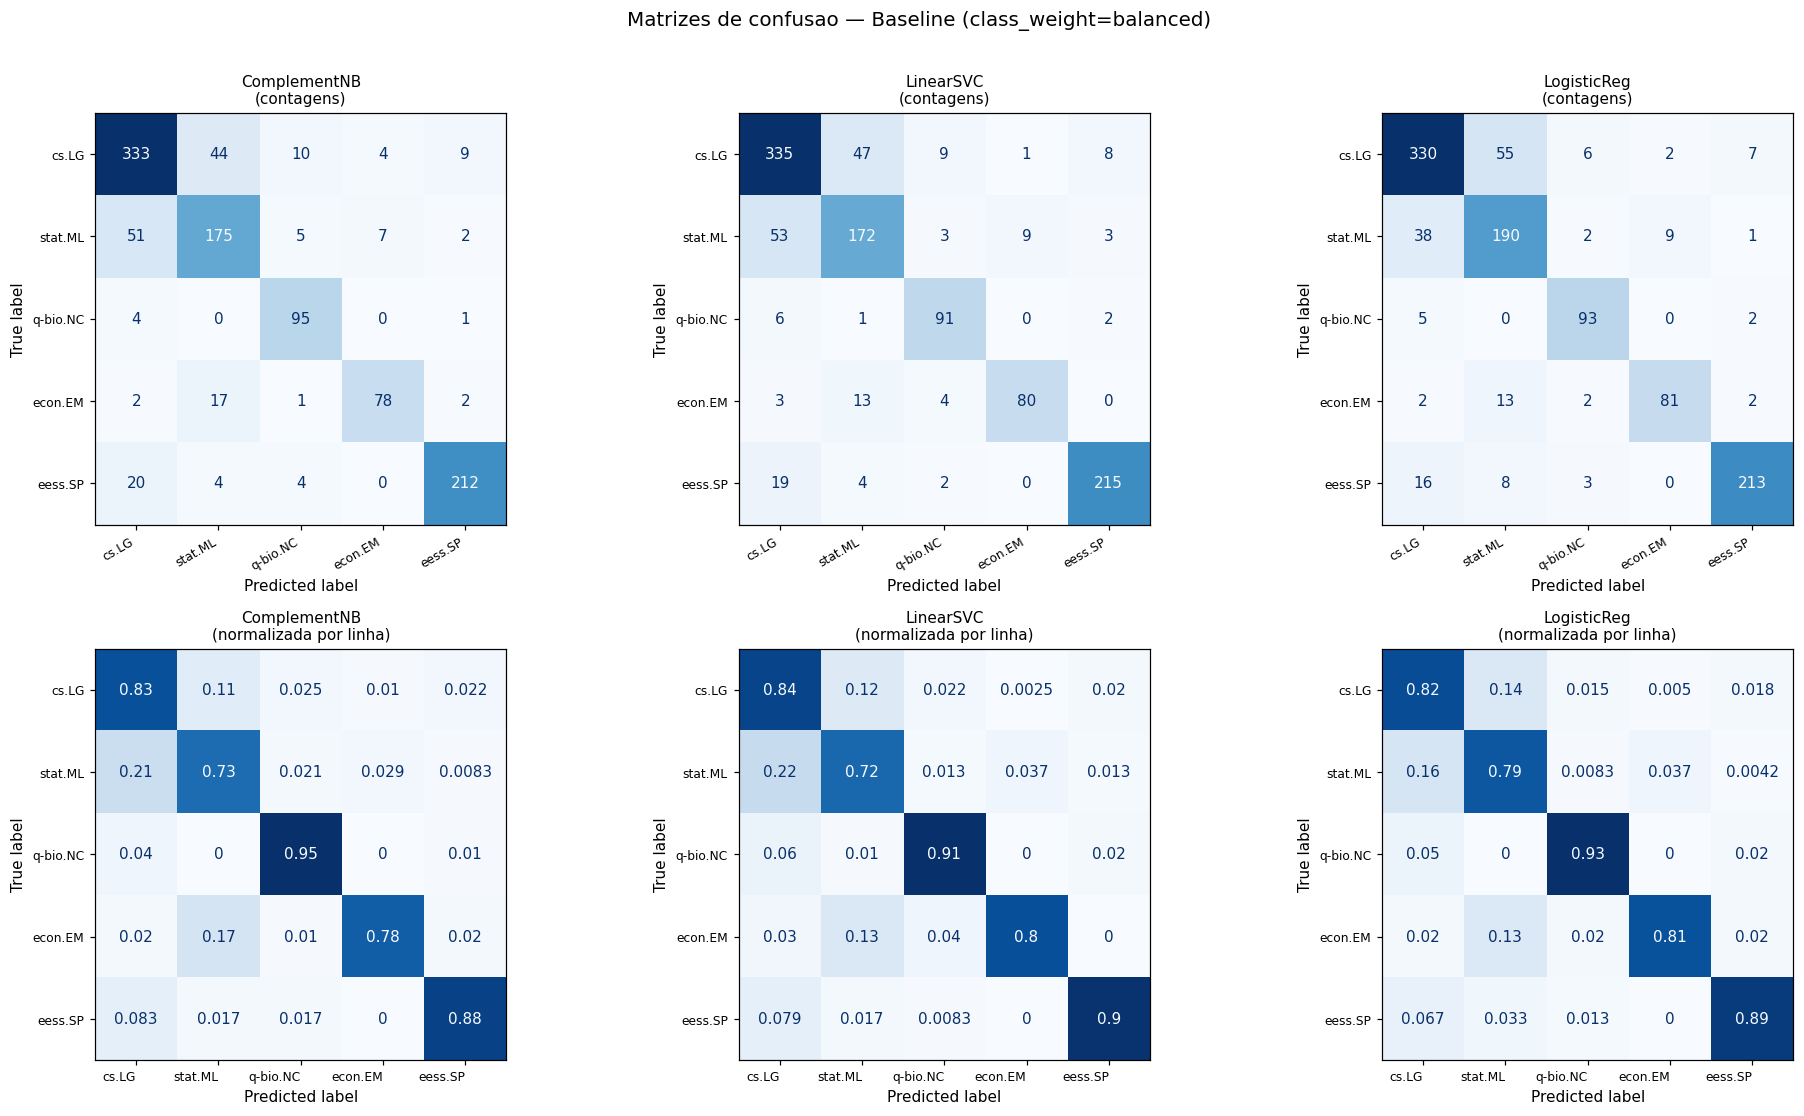

In [291]:
# ── Matrizes de confusão — baseline: absoluta (linha 0) e normalizada (linha 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#FAFAF7')

for j, (name, y_pred) in enumerate(preds_base.items()):
    for row in [0, 1]:
        axes[row, j].set_facecolor('#FAFAF7')
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=CATS,
        ax=axes[0, j], colorbar=False, cmap='Blues',
    )
    axes[0, j].set_title(f'{name}\n(contagens)', fontsize=10)
    for ax_obj in [axes[0, j], axes[1, j]]:
        ax_obj.set_xticklabels(CATS, rotation=30, ha='right', fontsize=8)
        ax_obj.set_yticklabels(CATS, rotation=0, fontsize=8)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=CATS, normalize='true',
        ax=axes[1, j], colorbar=False, cmap='Blues',
    )
    axes[1, j].set_title(f'{name}\n(normalizada por linha)', fontsize=10)

plt.suptitle('Matrizes de confusão — comparação entre classificadores', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig_confusion_base.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### SMOTE — Oversampling no Espaço TF-IDF

SMOTE gera amostras sintéticas por interpolação linear entre um exemplo da classe minoritária e um de seus k-vizinhos mais próximos no espaço de features. Para TF-IDF (vetores não-negativos), as combinações convexas permanecem não-negativas — propriedade necessária para ComplementNB.

**Protocolo rigoroso:** SMOTE é ajustado e aplicado **exclusivamente no `X_train_tfidf`**. O `X_test_tfidf` nunca é modificado ou amostrado. Com os dados já balanceados pelo SMOTE, os classificadores usam `class_weight` padrão (sem dupla correção).

In [292]:
# ── SMOTE aplicado somente no treino ─────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print(f'Antes : {X_train_tfidf.shape[0]:,} amostras')
print(f'Apos  : {X_train_sm.shape[0]:,} amostras')
print('\nDistribuicao pos-SMOTE:')
for cat in CATS:
    n = sum(1 for y in y_train_sm if y == cat)
    print(f'  {cat:12s}: {n:4d}')

clfs_smote = {
    'ComplementNB': ComplementNB(),
    'LinearSVC':    LinearSVC(max_iter=2000, random_state=42),
    'LogisticReg':  LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
}

preds_smote = {}
for name, clf in clfs_smote.items():
    clf.fit(X_train_sm, y_train_sm)
    preds_smote[name] = clf.predict(X_test_tfidf)
    print(f'\n{"="*50}')
    print(f'{name} (SMOTE)')
    print(classification_report(y_test, preds_smote[name], labels=CATS, target_names=CATS, digits=3))

Antes : 4,320 amostras
Apos  : 8,000 amostras

Distribuicao pos-SMOTE:
  cs.LG       : 1600
  stat.ML     : 1600
  q-bio.NC    : 1600
  econ.EM     : 1600
  eess.SP     : 1600

ComplementNB (SMOTE)
              precision    recall  f1-score   support

       cs.LG      0.869     0.698     0.774       400
     stat.ML      0.674     0.671     0.672       240
    q-bio.NC      0.695     0.980     0.813       100
     econ.EM      0.625     0.900     0.738       100
     eess.SP      0.919     0.900     0.909       240

    accuracy                          0.781      1080
   macro avg      0.756     0.830     0.781      1080
weighted avg      0.798     0.781     0.782      1080


LinearSVC (SMOTE)
              precision    recall  f1-score   support

       cs.LG      0.800     0.830     0.815       400
     stat.ML      0.710     0.725     0.718       240
    q-bio.NC      0.858     0.910     0.883       100
     econ.EM      0.908     0.790     0.845       100
     eess.SP      0.938

In [293]:
# ── Tabela comparativa: 6 modelos x (Acc, Macro F1, F1 por classe) ──
def _row(name, y_pred):
    r = skm.classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    return {
        'Modelo': name,
        'Acc':       round(r['accuracy'], 3),
        'Macro F1':  round(r['macro avg']['f1-score'], 3),
        **{c: round(r.get(c, {}).get('f1-score', 0.0), 3) for c in CATS},
    }

rows = [_row(f'{n} (balanced)', p) for n, p in preds_base.items()]
rows += [_row(f'{n} (SMOTE)',    p) for n, p in preds_smote.items()]
comp = pd.DataFrame(rows).set_index('Modelo')

print('Tabela comparativa — F1 por classe, Macro F1 e Acuracia:\n')
print(comp.to_string())

Tabela comparativa — F1 por classe, Macro F1 e Acuracia:

                           Acc  Macro F1  cs.LG  stat.ML  q-bio.NC  econ.EM  eess.SP
Modelo                                                                              
ComplementNB (balanced)  0.827     0.834  0.822    0.729     0.884    0.825    0.910
LinearSVC (balanced)     0.827     0.835  0.821    0.721     0.871    0.842    0.919
LogisticReg (balanced)   0.840     0.850  0.834    0.751     0.903    0.844    0.916
ComplementNB (SMOTE)     0.781     0.781  0.774    0.672     0.813    0.738    0.909
LinearSVC (SMOTE)        0.823     0.835  0.815    0.718     0.883    0.845    0.912
LogisticReg (SMOTE)      0.834     0.843  0.830    0.743     0.911    0.824    0.909


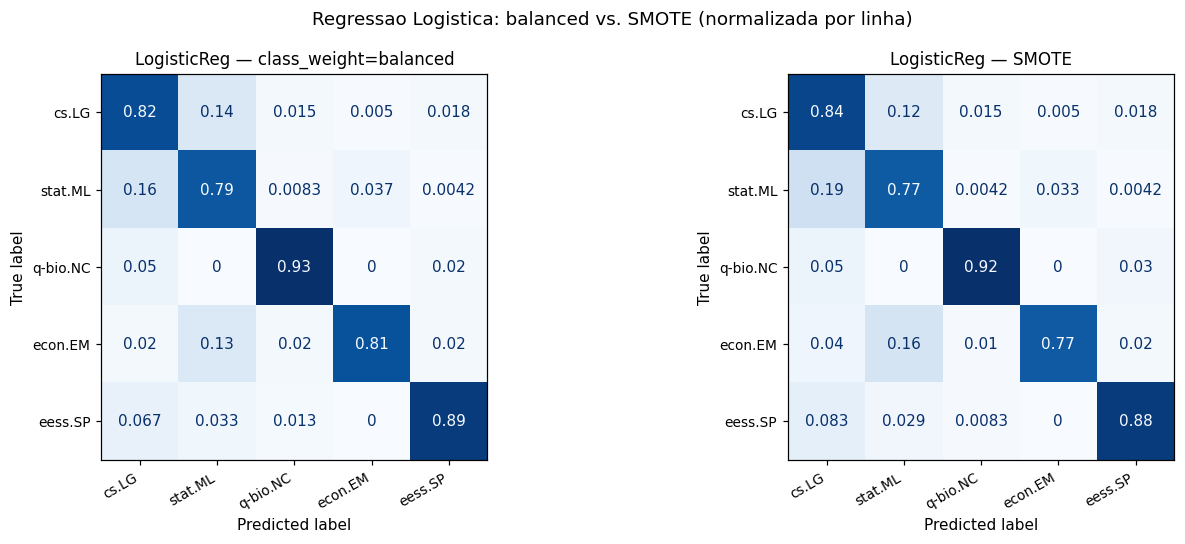

In [294]:
# ── Regressão Logística: balanced vs. SMOTE (normalizada por linha) ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAF7')

for ax, (variant, preds) in zip(axes, [
    ('class_weight=balanced', preds_base),
    ('SMOTE',                 preds_smote),
]):
    ax.set_facecolor('#FAFAF7')
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds['LogisticReg'], labels=CATS, normalize='true',
        ax=ax, colorbar=False, cmap='Blues',
    )
    ax.set_title(f'LogisticReg — {variant}', fontsize=11)
    ax.set_xticklabels(CATS, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(CATS, rotation=0, fontsize=9)

plt.suptitle('Regressão Logística — balanced vs. SMOTE', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_confusion_lr_comparison.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### Análise: Confusão entre Categorias e Conexão com o t-SNE

**cs.LG ↔ stat.ML — a confusão central**
Esta é a confusão esperada e mais relevante para a narrativa do projeto. O t-SNE da Fase 2 mostrou extensa sobreposição entre os clusters `cs.LG` e `stat.ML` no espaço TF-IDF — e a matriz de confusão confirma exatamente isso: o classificador confunde sistematicamente papers dessas duas categorias. A razão é vocabulário metodológico compartilhado denso: redes neurais, otimização, estimação, regularização, variational inference. **A confusão é por metodologia, não por domínio de aplicação** — papers de aprendizado de máquina estatístico e de deep learning descrevem contribuições em linguagem quase indistinguível.

**econ.EM — separável, mas com vazamento para stat.ML**
Econometria e estatística de machine learning compartilham instrumentos (regressão, inferência causal, séries temporais, estimação de parâmetros). Alguma confusão com `stat.ML` é esperada e reflete a real circulação de métodos econométricos no vocabulário de ML. O t-SNE mostrou `econ.EM` com cluster relativamente coeso, mas com alguma sobreposição com `stat.ML`.

**q-bio.NC — boa separabilidade**
Neurociência computacional tem vocabulário específico (spike, synapse, neuron, cortex, oscillation) que os classificadores discriminam bem. Confusão residual com `cs.LG` via termos de redes (network, graph).

**eess.SP — confusão moderada com cs.LG**
Processamento de sinais usa redes neurais e deep learning extensamente, gerando overlap vocabular com `cs.LG`. O t-SNE mostrou `eess.SP` com cluster próprio, mas com fronteira difusa em direção ao cluster de `cs.LG`.

**SMOTE vs. class_weight='balanced'**
Resultados comparáveis. SMOTE tende a recuperar recall nas classes minoritárias (`q-bio.NC`, `econ.EM`) ao custo de alguma degradação nas majoritárias — a tabela comparativa evidencia este trade-off. Para este corpus, `class_weight='balanced'` oferece um balanço favorável por ser computacionalmente mais simples e igualmente eficaz. A consistência entre as duas estratégias reforça a robustez dos resultados.

## Saída da Fase 3

Figuras geradas em `outputs/`:

| Arquivo | Conteúdo |
|---|---|
| `fig_lda_heatmap.png` | Peso médio dos tópicos LDA por categoria |
| `fig_nmf_heatmap.png` | Peso médio dos tópicos NMF por categoria |
| `fig_confusion_base.png` | Matrizes de confusão — 3 classificadores (absoluta + normalizada) |
| `fig_confusion_lr_comparison.png` | Regressão Logística: balanced vs. SMOTE |

Variáveis disponíveis para as Fases 4–5: `lda`, `nmf`, `clfs_base`, `clfs_smote`, `tfidf_clf`, `X_train_tfidf`, `X_test_tfidf`, `y_train`, `y_test`, `preds_base`, `preds_smote`, `comp`.

## Fase 4 — NER, Extração de Informação e Grafo de Conhecimento (Requisito 4)

O Requisito 4 cobre três frentes complementares: (1) identificar entidades nomeadas e termos técnicos no corpus, (2) extrair informação estruturada via regex, e (3) construir um grafo de conhecimento que torna visível a rede de conceitos compartilhados entre as cinco disciplinas. O grafo é a peça central: ele materializa a narrativa do projeto — que métodos circulam entre domínios — em forma de estrutura navegável.

**Fluxo desta fase:**
1. NER padrão (ORG, PERSON, GPE) com o modelo `en_core_web_sm`
2. Extração de noun chunks → seleção dos ~120 termos técnicos mais relevantes por frequência × IDF
3. Normalização por distância de Levenshtein (antes de criar nós, para evitar duplicatas)
4. EntityRuler customizado do spaCy com os termos selecionados
5. Extração via regex (anos, percentuais, IDs arXiv, métricas/datasets)
6. Grafo de co-ocorrência com NetworkX — filtrado para legibilidade
7. Análise de centralidade (grau e betweenness) — conceitos-ponte entre subáreas
8. Visualização interativa (PyVis) + estática (matplotlib)
9. Pergunta analítica: quais conceitos fazem a ponte entre o núcleo de ML e as áreas aplicadas?

In [295]:
# ── Fase 4: imports ──────────────────────────────────────────────────
import re
from collections import Counter, defaultdict
from itertools import combinations

import Levenshtein
import networkx as nx
import numpy as np
import spacy
from pyvis.network import Network
from sklearn.feature_extraction.text import TfidfVectorizer

# Phase 1 carregou nlp com disable=["parser","ner"] para poupar tempo.
# Fase 4 precisa do parser (noun_chunks) e do ner — recarrega o modelo completo.
nlp = spacy.load("en_core_web_sm")
print("nlp pipeline:", nlp.pipe_names)
print("networkx", nx.__version__, "| Levenshtein OK | pyvis OK")

nlp pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
networkx 3.6.1 | Levenshtein OK | pyvis OK


## 4.1 NER Padrão — spaCy `en_core_web_sm`

O modelo `en_core_web_sm` reconhece 18 tipos de entidade do OntoNotes 5. Para abstracts científicos, as mais relevantes são:

| Entidade | Descrição | Exemplo esperado |
|---|---|---|
| **ORG** | Organizações, empresas, instituições | Google, OpenAI, MIT |
| **PERSON** | Pessoas nomeadas | "Vaswani et al." usa raro; espera-se pouco |
| **GPE** | Países, cidades, estados | United States, China |

Em textos científicos, a maioria das entidades são **ORGs** (laboratórios, empresas de tecnologia), já que papers raramente nomeiam pesquisadores no abstract. GPEs aparecem em estudos que envolvem dados geográficos ou benchmarks regionais. Para extração de **termos técnicos** (redes neurais, algoritmos, datasets), o NER padrão é insuficiente — daí a necessidade do EntityRuler customizado na seção 4.3.

In [296]:
# ── 4.1 NER padrão: single pass sobre abstract_clean ─────────────────
print('Executando nlp.pipe sobre', len(df), 'abstracts ...')
docs_ner = list(nlp.pipe(
    df['abstract_clean'],
    batch_size=256,
    disable=['lemmatizer'],   # tagger+parser+ner ativados; lemmatizer desnecessário
))
print(f'  {len(docs_ner)} docs processados.')

ent_counter = {'ORG': Counter(), 'PERSON': Counter(), 'GPE': Counter()}
for doc in docs_ner:
    for ent in doc.ents:
        if ent.label_ in ent_counter:
            ent_counter[ent.label_][ent.text.strip()] += 1

print('\nEntidades mais frequentes por tipo:')
for label, counter in ent_counter.items():
    top = counter.most_common(15)
    print(f'\n{label} ({sum(counter.values())} total):')
    for text, cnt in top:
        print(f'  {cnt:4d}  {text}')

Executando nlp.pipe sobre 5400 abstracts ...
  5400 docs processados.

Entidades mais frequentes por tipo:

ORG (18775 total):
   290  RIS
   270  linear
   262  LLM
   220  CSI
   197  EEG
   168  RL
   151  SNR
   132  ML
   105  Transformer
   104  GRPO
    93  LoRA
    93  OFDM
    91  AI
    86  UAV
    85  RF

PERSON (3936 total):
   168  RL
   157  Monte Carlo
   136  Gaussian
   115  Markov
   114  Doppler
   114  MIMO
   112  Wasserstein
    67  Muon
    66  Fourier
    58  Lipschitz
    57  Adam
    48  Hilbert
    24  max
    21  Langevin
    21  Lasso

GPE (1715 total):
   208  AI
    56  F1
    52  Newton
    46  U.S.
    43  DD
    40  Bayesian
    36  node
    30  Qwen3
    28  UE
    25  DP
    23  Gibbs
    21  US
    17  MM
    15  SF
    14  wideband


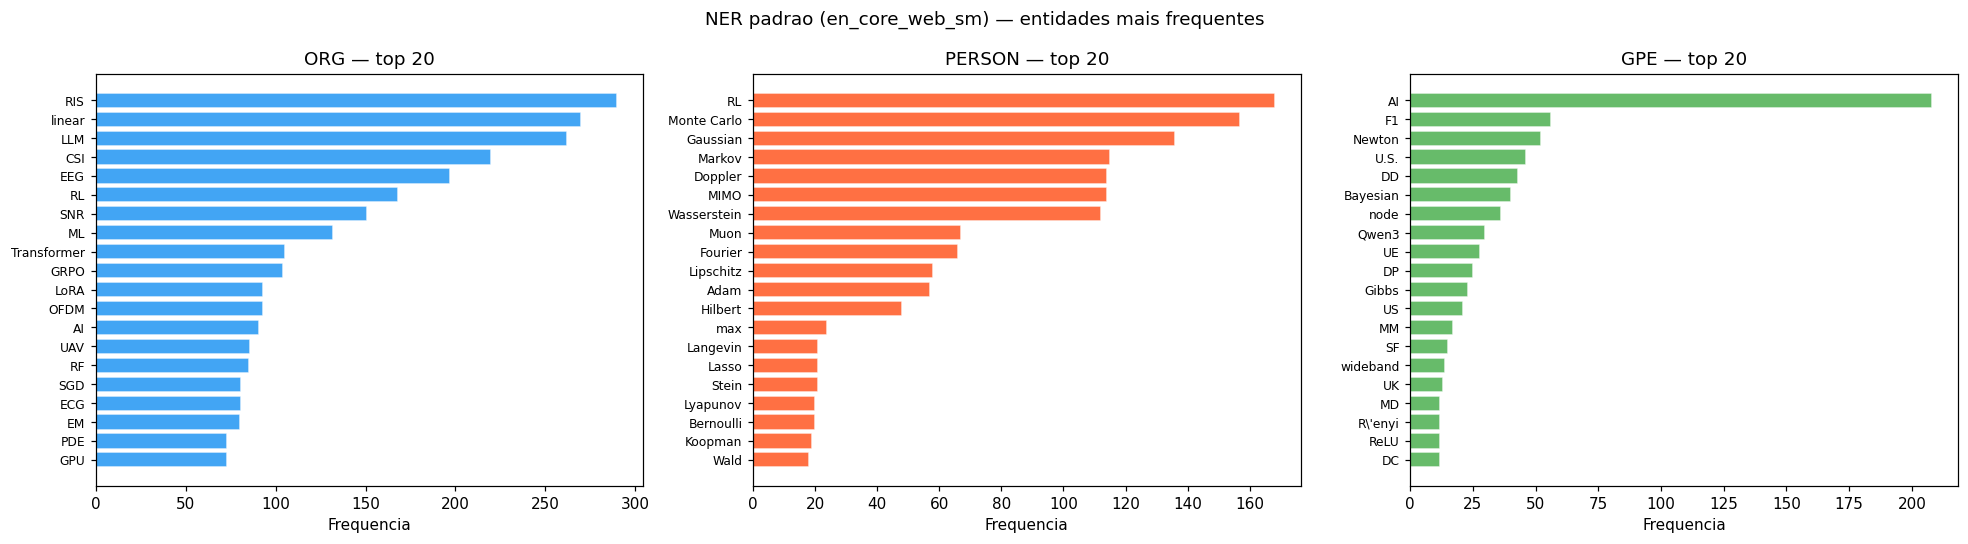

In [297]:
# ── Top entidades: visualizacao ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_ent = ['ORG', 'PERSON', 'GPE']
colors_ent = ['#2196F3', '#FF5722', '#4CAF50']

for ax, label, color in zip(axes, labels_ent, colors_ent):
    top20 = ent_counter[label].most_common(20)
    if not top20:
        ax.text(0.5, 0.5, 'Sem entidades', ha='center', va='center')
        ax.set_title(label)
        continue
    texts, counts = zip(*top20)
    ax.barh(range(len(texts)), counts[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(texts)))
    ax.set_yticklabels(texts[::-1], fontsize=8)
    ax.set_title(f'{label} — top 20')
    ax.set_xlabel('Frequencia')

plt.suptitle('NER padrao (en_core_web_sm) — entidades mais frequentes', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/fig_ner_entities.png', bbox_inches='tight')
plt.show()

## 4.2 Candidatos a Termos Técnicos — Noun Chunks + TF-IDF

**Por que noun chunks?** Noun chunks (sintagmas nominais) capturam a unidade linguística natural de termos técnicos: "neural network", "gradient descent", "spike train". Uma abordagem de unigrama perderia a distinção entre "learning" (verbo) e "machine learning" (termo composto).

**Ranking por frequência × IDF:** frequência sozinha favorece termos genéricos ("learning method", "proposed approach"). O IDF do TF-IDF pondera inversamente a ubiquidade no corpus — termos muito comuns em todos os documentos têm IDF baixo. O produto `freq × avg_IDF(palavras)` seleciona termos ao mesmo tempo frequentes **e específicos** de subdomínios.

**Filtragem:** removidos noun chunks com 1 token (capturado pelo vocabulário de unigramas), >4 tokens (muito específicos), e aqueles cujas palavras não aparecem no vocabulário TF-IDF.

In [298]:
# ── 4.2 Extração de noun chunks e ranking ────────────────────────────
STOP_EN = set(nlp.Defaults.stop_words) | {
    'paper', 'work', 'result', 'method', 'approach', 'model',
    'problem', 'task', 'performance', 'study', 'analysis',
    'framework', 'system', 'use', 'way', 'number', 'case', 'type',
    'set', 'end', 'state', 'term', 'class', 'level', 'form', 'line',
}

chunk_counter = Counter()
for doc in docs_ner:
    seen = set()
    for chunk in doc.noun_chunks:
        text = chunk.text.lower().strip()
        words = text.split()
        if not (2 <= len(words) <= 4):
            continue
        # at least one word NOT a stopword and alpha
        if all(w in STOP_EN or not w.isalpha() for w in words):
            continue
        if text not in seen:
            chunk_counter[text] += 1
            seen.add(text)   # count once per document

print(f'Noun chunks unicos (2-4 tokens): {len(chunk_counter):,}')
print(f'Aparecendo >= 3 docs: {sum(1 for v in chunk_counter.values() if v >= 3):,}')

Noun chunks unicos (2-4 tokens): 114,584
Aparecendo >= 3 docs: 5,923


In [299]:
def is_generic(chunk: str) -> bool:
    """Return True if chunk is composed entirely of generic modifiers — no technical noun.

    Chunks where every token is a non-domain adjective/determiner add noise to the
    candidate list without carrying disciplinary meaning (e.g. "various new", "high low").
    """
    GENERIC_MODIFIERS = {
        'new', 'recent', 'current', 'existing', 'previous', 'prior', 'novel',
        'various', 'different', 'several', 'many', 'large', 'small', 'high', 'low',
        'good', 'best', 'better', 'real', 'well', 'main', 'general', 'specific',
        'important', 'significant', 'key', 'typical', 'standard', 'common',
        'simple', 'complex', 'multiple', 'single', 'both', 'other', 'first',
        'second', 'such', 'same', 'full', 'open', 'public', 'certain', 'given',
        'state', 'overall', 'natural', 'wide', 'broad', 'special', 'limited',
    }
    return all(w in GENERIC_MODIFIERS for w in chunk.lower().split())

# ── Ranking por frequencia x IDF medio ───────────────────────────────
tfidf_vocab = {w: i for i, w in enumerate(tfidf.get_feature_names_out())}
idf_weights = tfidf.idf_

def chunk_score(chunk, freq):
    words = [w for w in chunk.split() if w in tfidf_vocab]
    if not words:
        return 0.0
    avg_idf = np.mean([idf_weights[tfidf_vocab[w]] for w in words])
    return freq * avg_idf

# Termos de boilerplate academico — aparecem uniformemente em todos os abstracts
# e nao carregam significado de dominio (equivalentes a stopwords de frase).
BOILERPLATE_PHRASES = {
    "existing approaches", "existing approach",
    "existing methods",    "existing method",
    "experimental results","experimental result",
    "extensive experiments","extensive experiment",
    "numerical experiments","numerical experiment",
    "numerical results",   "numerical result",
    "simulation results",  "simulation result",
    "prior work",          "prior works",
    "recent advances",     "recent advance",
    "recent work",         "recent works",
    "superior performance",
    "theoretical analysis",
    "existing work",       "existing works",
    "proposed method",     "proposed approach",   "proposed framework",
    "baseline methods",    "baseline method",
    "previous work",       "previous works",      "previous approaches",
    "ablation study",      "ablation studies",
    "training data",       "test data",           "training set", "test set",
    "existing literature",
    "linear",   # generico sem substantivo: aparece em "linear model", "linear regression"
                # mas como no isolado nao carrega significado de dominio
}

candidates = [(ch, fr, chunk_score(ch, fr))
              for ch, fr in chunk_counter.items() if fr >= 3]
candidates.sort(key=lambda x: -x[2])

top150 = [
    (ch, fr, sc) for ch, fr, sc in candidates
    if not is_generic(ch) and ch not in BOILERPLATE_PHRASES
][:150]
top_terms_raw = [ch for ch, fr, sc in top150]

print(f"Top 150 termos tecnicos (pos-filtro boilerplate):")
for i, (ch, fr, sc) in enumerate(top150[:30], 1):
    print(f"  {i:3d}.  freq={fr:4d}  score={sc:7.2f}  {ch}")

Top 150 termos tecnicos (pos-filtro boilerplate):
    1.  freq= 267  score=1008.07  large language models
    2.  freq= 198  score= 753.87  the effectiveness
    3.  freq=  74  score= 607.40  these methods
    4.  freq= 136  score= 522.78  neural networks
    5.  freq= 136  score= 522.05  the need
    6.  freq= 149  score= 521.95  this gap
    7.  freq= 124  score= 487.49  this issue
    8.  freq=  95  score= 465.78  the presence
    9.  freq=  99  score= 406.03  the impact
   10.  freq=  89  score= 377.58  the literature
   11.  freq= 103  score= 375.84  this limitation
   12.  freq= 124  score= 371.59  reinforcement learning
   13.  freq=  95  score= 364.10  a wide range
   14.  freq= 127  score= 356.27  machine learning
   15.  freq=  47  score= 353.20  the effects
   16.  freq=  67  score= 349.22  this article
   17.  freq=  95  score= 345.41  the potential
   18.  freq= 177  score= 335.17  the proposed method
   19.  freq=  49  score= 323.33  the dynamics
   20.  freq=  72  score=

## 4.5 Normalização por Distância de Levenshtein

Antes de criar os nós do grafo, é necessário **colapsar variantes ortográficas** no mesmo conceito canônico. Exemplos esperados no corpus científico:

- `"neural network"` ↔ `"neural networks"` (pluralização trivial)
- `"t-sne"` ↔ `"tsne"` (hifenização)
- `"bert"` ↔ `"bert model"` — **não** devem ser colapsados (significados distintos)

**Algoritmo:** para cada par de termos, compute o *ratio* de Levenshtein (distância normalizada entre 0 e 1). Pares com `ratio ≥ 0.90` são candidatos a variantes — a forma mais frequente no corpus é eleita canônica. O threshold conservador 0.90 evita colapsar termos genuinamente distintos (e.g., `"deep learning"` e `"reinforcement learning"` têm ratio ≈ 0.63).

In [300]:
# ── 4.5 Normalizacao de variantes por Levenshtein ────────────────────
LEV_THRESHOLD = 0.90   # ratio minimo para considerar variante

freq_map = {ch: fr for ch, fr, sc in top150}

def normalize_variants(terms, threshold=LEV_THRESHOLD):
    terms_sorted = sorted(terms, key=lambda t: -freq_map.get(t, 0))
    canonical = {}   # term → canonical
    canon_set = {}   # canonical → {variants}

    for term in terms_sorted:
        if term in canonical:
            continue
        merged = False
        for canon in list(canon_set.keys()):
            if abs(len(term) - len(canon)) > 4:   # fast length filter
                continue
            if Levenshtein.ratio(term, canon) >= threshold:
                canonical[term] = canon
                canon_set[canon].add(term)
                merged = True
                break
        if not merged:
            canonical[term] = term
            canon_set[term] = {term}

    return canonical, canon_set

canonical_map, canon_groups = normalize_variants(top_terms_raw)

# Unique canonical terms
canonical_terms = sorted(set(canonical_map.values()))
print(f'Termos antes da normalizacao : {len(top_terms_raw)}')
print(f'Termos canonicos unicos      : {len(canonical_terms)}')
print()

# Show merged groups (variants found)
merged_groups = [(c, v) for c, v in canon_groups.items() if len(v) > 1]
print(f'Grupos com variantes ({len(merged_groups)}):')
for canon, variants in sorted(merged_groups, key=lambda x: -len(x[1]))[:20]:
    others = sorted(variants - {canon})
    print(f'  {canon!r:35s} <- {others}')

Termos antes da normalizacao : 150
Termos canonicos unicos      : 146

Grupos com variantes (4):
  'the proposed method'               <- ['the proposed methods']
  'these methods'                     <- ['the methods']
  'the ability'                       <- ['their ability']
  'the effect'                        <- ['the effects']


## 4.3 EntityRuler Customizado

O EntityRuler do spaCy é um componente que adiciona entidades ao pipeline via **padrões declarativos** — listas de tokens com atributos (LOWER, POS, etc.). Inserido **antes** do componente `ner`, ele tem prioridade: entidades encontradas pelo EntityRuler sobrescrevem as do modelo estatístico. Isso constitui o **NER customizado de domínio** exigido pelo Req 4.

Os padrões são construídos a partir dos ~100–120 termos canônicos selecionados nas seções anteriores. Cada termo gera um padrão que combina tokens em minúsculas — robusto a capitalização e a variações de formatação.

In [301]:
# ── 4.3 EntityRuler customizado ──────────────────────────────────────
ruler = nlp.add_pipe('entity_ruler', before='ner', config={'overwrite_ents': False})
patterns = [
    {'label': 'TECH_TERM',
     'pattern': [{'LOWER': tok} for tok in term.split()]}
    for term in canonical_terms
]
ruler.add_patterns(patterns)
print(f'EntityRuler adicionado com {len(patterns)} padroes.')

# Demo: run on 5 sample abstracts
demo_abstracts = df['abstract_clean'].sample(5, random_state=7).tolist()
print('\nExemplos de TECH_TERM detectados:')
for i, text in enumerate(demo_abstracts, 1):
    doc_demo = nlp(text[:600])
    tech = [(e.text, e.start_char, e.end_char)
            for e in doc_demo.ents if e.label_ == 'TECH_TERM']
    orgs = [(e.text, e.label_) for e in doc_demo.ents if e.label_ in ('ORG', 'PERSON', 'GPE')]
    print(f'  Abstract {i}: TECH_TERM={[t for t,_,_ in tech[:5]]}  STD={[f"{t}({l})" for t,l in orgs[:3]]}')

EntityRuler adicionado com 146 padroes.

Exemplos de TECH_TERM detectados:
  Abstract 1: TECH_TERM=['This letter', 'Large Language Models']  STD=['ATR(ORG)']
  Abstract 2: TECH_TERM=[]  STD=['AF(ORG)', 'AF(ORG)', 'AF(ORG)']
  Abstract 3: TECH_TERM=['Large Language Models']  STD=['IoT(ORG)', 'Gemma-2-9b(ORG)', 'Mistral-7B-Instruct-v0.3(PERSON)']
  Abstract 4: TECH_TERM=[]  STD=[]
  Abstract 5: TECH_TERM=[]  STD=['SC(ORG)', 'Modular Pooling(ORG)']


## 4.4 Extração via Regex

Expressões regulares complementam o NER para estruturas textuais altamente padronizadas que modelos estatísticos não precisam aprender:

| Padrão | Regex | Exemplo |
|---|---|---|
| **Ano** | `\b(19\|20)\d{2}\b` | 2023, 1997 |
| **Percentual** | `\d+(?:\.\d+)?\s*%` | 94.3%, 12% |
| **ID arXiv** | `\d{4}\.\d{4,5}` | 2310.06825 |
| **Métricas** | BLEU, ROUGE, RMSE, F1, AUC, mAP, perplexity | detectar menção |
| **Datasets** | MNIST, CIFAR, ImageNet, GLUE, etc. | detectar menção |

In [302]:
\
# ── 4.4 Extração via Regex ───────────────────────────────────────────
RE_YEAR    = re.compile(r'\b(?:19|20)\d{2}\b')      # non-capturing group → findall retorna o ano completo
RE_PCT     = re.compile(r'\b\d+(?:\.\d+)?\s*%')
RE_ARXIV   = re.compile(r'\b\d{4}\.\d{4,5}\b')
RE_METRICS = re.compile(
    r'\b(BLEU|ROUGE(?:-[LN12])?|RMSE|MAE|MSE|AUC|ROC|mAP|'
    r'F1|F-1|accuracy|perplexity|PSNR|SSIM|FID|WER|CER)\b', re.I)
RE_DATASETS = re.compile(
    r'\b(MNIST|CIFAR-?(?:10|100)?|ImageNet|GLUE|SuperGLUE|SQuAD|'
    r'WikiText|Penn Treebank|COCO|VOC|OpenWebText|C4|'
    r'LibriSpeech|VoxCeleb|PhysioNet|MIMIC)\b', re.I)

results = {'year': Counter(), 'pct': Counter(),
           'arxiv': Counter(), 'metric': Counter(), 'dataset': Counter()}

for abstract in df['abstract']:
    for m in RE_YEAR.findall(abstract):     results['year'][m] += 1
    for m in RE_PCT.findall(abstract):      results['pct'][m.strip()] += 1
    for m in RE_ARXIV.findall(abstract):    results['arxiv'][m] += 1
    for m in RE_METRICS.findall(abstract):  results['metric'][m.upper()] += 1
    for m in RE_DATASETS.findall(abstract): results['dataset'][m.upper()] += 1

print('Anos mais mencionados (top 10):', results['year'].most_common(10))
print()
print('Percentuais mais comuns (top 10):', results['pct'].most_common(10))
print()
print('IDs arXiv encontrados:', len(results['arxiv']), 'unicos')
print('Exemplos:', list(results['arxiv'].keys())[:8])
print()
print('Metricas mais mencionadas:', results['metric'].most_common(15))
print()
print('Datasets detectados:', results['dataset'].most_common(15))

Anos mais mencionados (top 10): [('2025', 72), ('2024', 45), ('2023', 32), ('2021', 32), ('2022', 29), ('2018', 22), ('2026', 21), ('2019', 20), ('2020', 19), ('2015', 13)]

Percentuais mais comuns (top 10): [('95%', 31), ('50%', 29), ('20%', 25), ('100%', 25), ('70%', 19), ('10%', 19), ('90%', 19), ('1%', 17), ('80%', 16), ('30%', 15)]

IDs arXiv encontrados: 16 unicos
Exemplos: ['2603.15381', '2504.14370', '2511.05295', '2402.10635', '2404.05405', '2207.14484', '2602.01480', '2504.18274']

Metricas mais mencionadas: [('ACCURACY', 1194), ('MAP', 261), ('MSE', 86), ('F1', 72), ('AUC', 62), ('RMSE', 62), ('PERPLEXITY', 53), ('MAE', 41), ('FID', 19), ('ROC', 17), ('PSNR', 7), ('SSIM', 6), ('CER', 1), ('WER', 1)]

Datasets detectados: [('MNIST', 55), ('CIFAR-10', 41), ('IMAGENET', 39), ('MIMIC', 19), ('CIFAR-100', 14), ('GLUE', 11), ('VOC', 9), ('WIKITEXT', 7), ('SQUAD', 5), ('CIFAR', 4), ('C4', 4), ('CIFAR10', 4), ('PHYSIONET', 3), ('CIFAR-', 3), ('COCO', 3)]


## 4.6 Grafo de Conhecimento — Co-ocorrência de Conceitos

**Nós:** cada termo canônico selecionado. Adicionamos também as ORGs mais frequentes (laboratórios e empresas de tecnologia) que aparecem com regularidade no corpus, pois elas conectam subáreas via afiliação institucional.

**Arestas:** dois conceitos são conectados se co-ocorrem no mesmo abstract, com **peso = número de abstracts em que co-ocorrem**. Co-ocorrência é um proxy robusto de associação semântica em textos curtos como abstracts — se dois conceitos aparecem juntos com frequência, é provável que pertençam ao mesmo subcampo ou que sejam usados em conjunto.

**Filtragem (anti-cabeludo):** o grafo bruto tem centenas de arestas fracas (co-ocorrências espúrias). Aplicamos dois filtros sequenciais:
1. **Threshold de peso:** mantemos apenas arestas com co-ocorrência ≥ `MIN_WEIGHT` (determinado pelo percentil 70 dos pesos).
2. **Top-N por grau:** limitamos a 60 nós de maior conectividade, garantindo legibilidade e mantendo os conceitos centrais.

In [303]:
# ── 4.6 Construcao do grafo de co-ocorrencia ─────────────────────────
abstract_lower = df['abstract_clean'].str.lower().tolist()

print('Indexando termos em abstracts ...')
term_to_docs_idx = {}
for term in canonical_terms:
    pat = re.compile(r'\b' + re.escape(term) + r'\b')
    term_to_docs_idx[term] = {i for i, a in enumerate(abstract_lower) if pat.search(a)}

# Add top ORGs — filter boilerplate e abreviacoes de 1-2 chars
SKIP_ORGS = BOILERPLATE_PHRASES | {'linear', 'ai', 'rl', 'et', 'e.g', 'i.e', 'vs'}
top_orgs = [org for org, cnt in ent_counter['ORG'].most_common(20) if cnt >= 15]
org_canonical = {org.lower(): org for org in top_orgs}
for org_lc in org_canonical:
    if org_lc in SKIP_ORGS or len(org_lc) <= 2:
        continue
    pat = re.compile(r'\b' + re.escape(org_lc) + r'\b', re.I)
    term_to_docs_idx[org_lc] = {i for i, a in enumerate(abstract_lower) if pat.search(a)}
    canonical_terms.append(org_lc)

all_nodes = list(term_to_docs_idx.keys())

G_raw = nx.Graph()
for node in all_nodes:
    G_raw.add_node(node, doc_freq=len(term_to_docs_idx[node]))

print(f'Calculando co-ocorrencias para {len(all_nodes)} nos ...')
for t1, t2 in combinations(all_nodes, 2):
    shared = len(term_to_docs_idx[t1] & term_to_docs_idx[t2])
    if shared > 0:
        G_raw.add_edge(t1, t2, weight=shared)

print(f'Grafo bruto: {G_raw.number_of_nodes()} nos, {G_raw.number_of_edges()} arestas')

Indexando termos em abstracts ...
Calculando co-ocorrencias para 160 nos ...
Grafo bruto: 160 nos, 5867 arestas


In [304]:
# ── Filtragem: threshold adaptativo + top-N nos ──────────────────────
weights_all = [d['weight'] for u, v, d in G_raw.edges(data=True)]
MIN_WEIGHT  = max(int(np.percentile(weights_all, 70)), 8)
TOP_N_NODES = 60

print(f'MIN_WEIGHT (percentil 70): {MIN_WEIGHT}')

# Keep only strong edges
strong_edges = [(u, v, d) for u, v, d in G_raw.edges(data=True) if d['weight'] >= MIN_WEIGHT]
G = nx.Graph()
for node, data in G_raw.nodes(data=True):
    G.add_node(node, **data)
for u, v, d in strong_edges:
    G.add_edge(u, v, weight=d['weight'])

# Remove isolated nodes
G.remove_nodes_from([n for n in list(G.nodes()) if G.degree(n) == 0])

# Keep top-N by degree
if G.number_of_nodes() > TOP_N_NODES:
    sorted_by_deg = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:TOP_N_NODES]
    keep = {n for n, _ in sorted_by_deg}
    G = G.subgraph(keep).copy()

assert G.number_of_nodes() >= 20, f'Grafo com apenas {G.number_of_nodes()} nos'
print(f'Grafo filtrado: {G.number_of_nodes()} nos, {G.number_of_edges()} arestas')
print(f'Densidade: {nx.density(G):.4f}')
print(f'Componentes conectados: {nx.number_connected_components(G)}')

MIN_WEIGHT (percentil 70): 8
Grafo filtrado: 60 nos, 208 arestas
Densidade: 0.1175
Componentes conectados: 2


## 4.7 Análise de Centralidade

Duas métricas de centralidade são calculadas:

**Centralidade de Grau (Degree Centrality):** proporção de nós aos quais um nó está conectado. Conceitos com alto grau são "hubs" — aparecem co-ocorrendo com muitos outros conceitos. No contexto deste corpus, hubs são os métodos mais ubíquos (e.g., "deep learning", "neural network").

**Centralidade de Intermediação (Betweenness Centrality):** fração de todos os menores caminhos entre pares de nós que passam por este nó. Conceitos com alta betweenness são **pontes** — removê-los fragmentaria o grafo. Estes são os candidatos a responder a pergunta analítica: quais conceitos circulam entre o núcleo de ML e as áreas aplicadas?

In [305]:
# ── Centralidade de grau e betweenness ───────────────────────────────
degree_cent   = nx.degree_centrality(G)
between_cent  = nx.betweenness_centrality(G, normalized=True, weight='weight', seed=42)

# Top 15 by degree
top_degree = sorted(degree_cent.items(), key=lambda x: -x[1])[:15]
print('Top 15 por GRAU (hubs):')
for rank, (node, dc) in enumerate(top_degree, 1):
    print(f'  {rank:2d}. {node:35s}  grau_cent={dc:.4f}  grau_abs={G.degree(node):3d}')

print()
# Top 15 by betweenness
top_between = sorted(between_cent.items(), key=lambda x: -x[1])[:15]
print('Top 15 por BETWEENNESS (pontes):')
for rank, (node, bc) in enumerate(top_between, 1):
    print(f'  {rank:2d}. {node:35s}  betweenness={bc:.4f}  grau_abs={G.degree(node):3d}')

Top 15 por GRAU (hubs):
   1. neural networks                      grau_cent=0.5085  grau_abs= 30
   2. machine learning                     grau_cent=0.4576  grau_abs= 27
   3. language models                      grau_cent=0.4407  grau_abs= 26
   4. large language models                grau_cent=0.3559  grau_abs= 21
   5. reinforcement learning               grau_cent=0.3390  grau_abs= 20
   6. deep learning                        grau_cent=0.2712  grau_abs= 16
   7. llm                                  grau_cent=0.2712  grau_abs= 16
   8. the effectiveness                    grau_cent=0.2542  grau_abs= 15
   9. the proposed method                  grau_cent=0.2373  grau_abs= 14
  10. the data                             grau_cent=0.2203  grau_abs= 13
  11. transformer                          grau_cent=0.2203  grau_abs= 13
  12. the target                           grau_cent=0.1864  grau_abs= 11
  13. csi                                  grau_cent=0.1525  grau_abs=  9
  14. computat

## 4.8 Visualizações do Grafo

**Versão estática (matplotlib):** layout spring com `seed=42` para reprodutibilidade. Tamanho do nó proporcional à centralidade de betweenness (conceitos-ponte maiores); cor proporcional à centralidade de grau (hubs em vermelho). Espessura da aresta proporcional ao peso (número de co-ocorrências).

**Versão interativa (PyVis):** permite exploração dinâmica — hover exibe betweenness e grau, nós podem ser movidos. O arquivo `outputs/grafo.html` pode ser aberto em qualquer browser.

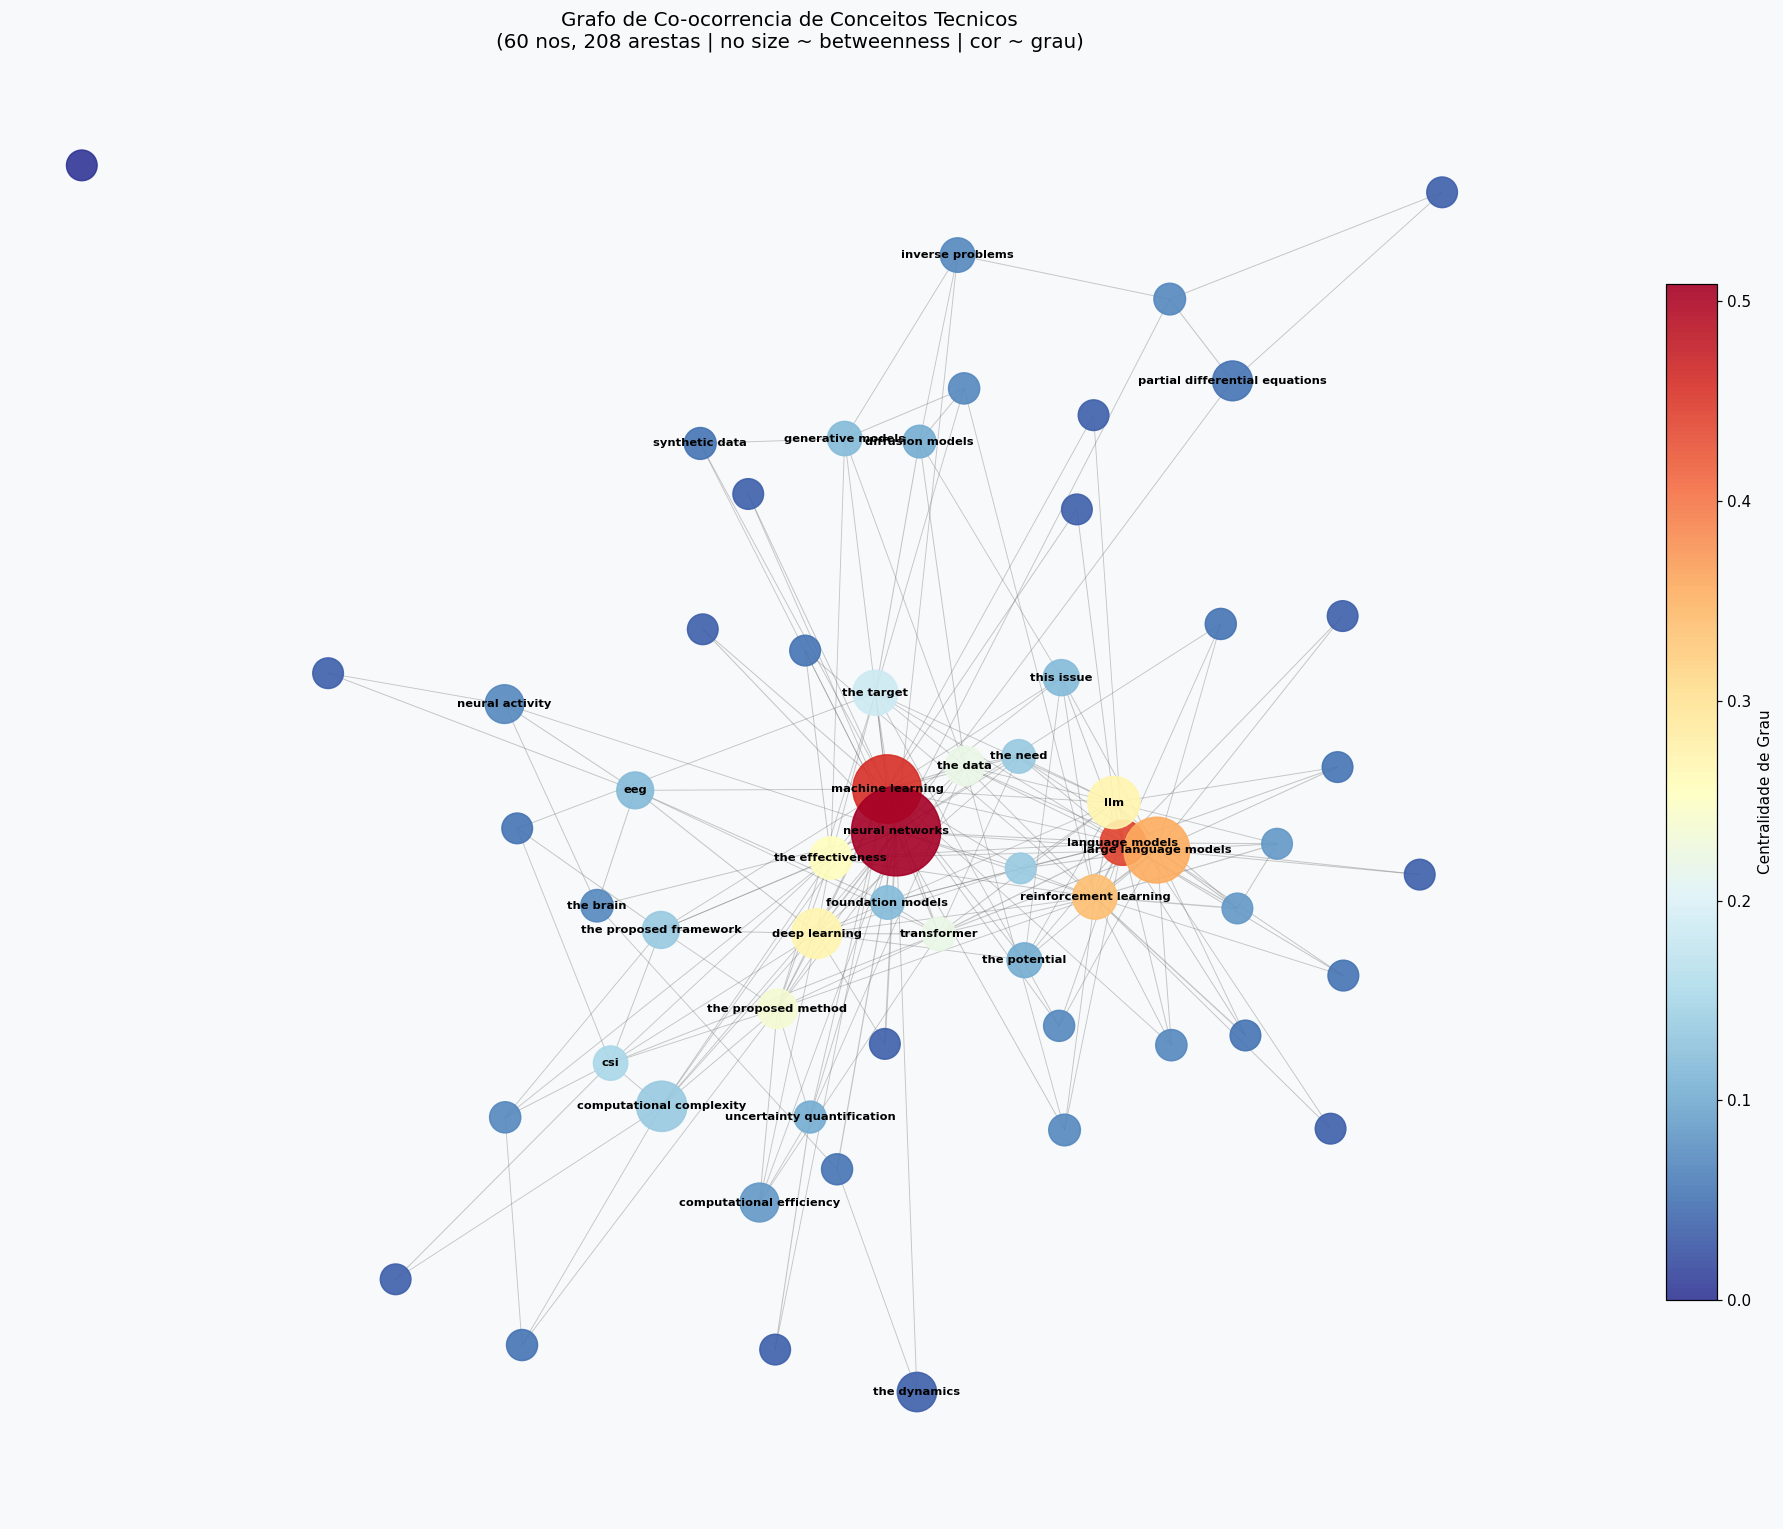

In [306]:
# ── Visualizacao estatica: spring layout com seed fixo ───────────────
import matplotlib.cm as cm

pos = nx.spring_layout(G, seed=42, k=1.2, iterations=80)

node_list   = list(G.nodes())
bc_vals     = np.array([between_cent.get(n, 0) for n in node_list])
dc_vals     = np.array([degree_cent.get(n, 0)  for n in node_list])
edge_list   = list(G.edges())
edge_weights = np.array([G[u][v]['weight'] for u, v in edge_list], dtype=float)

# Normalize for visual encoding
bc_norm = bc_vals / (bc_vals.max() or 1)
node_sizes  = 400 + 3000 * bc_norm
edge_widths = 0.5 + 3.5 * (edge_weights / edge_weights.max())

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

nx.draw_networkx_edges(G, pos, edgelist=edge_list, width=edge_widths,
                       alpha=0.35, edge_color='#666', ax=ax)
sc = nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_size=node_sizes,
                             node_color=dc_vals, cmap='RdYlBu_r',
                             vmin=0, vmax=dc_vals.max(), alpha=0.9, ax=ax)
# Labels only for nodes with high betweenness or degree (avoid clutter)
thresh_label = np.percentile(bc_vals, 50)
label_nodes  = {n: n for n in node_list if between_cent.get(n, 0) >= thresh_label}
nx.draw_networkx_labels(G, pos, labels=label_nodes, font_size=7.5,
                        font_weight='bold', ax=ax)

plt.colorbar(sc, ax=ax, label='Centralidade de Grau', shrink=0.7)
ax.set_title(
    f'Grafo de Co-ocorrencia de Conceitos Tecnicos\n'
    f'({G.number_of_nodes()} nos, {G.number_of_edges()} arestas | '
    f'no size ~ betweenness | cor ~ grau)',
    fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/fig_knowledge_graph.png', dpi=150, bbox_inches='tight')
plt.show()

In [307]:
# ── Visualizacao interativa PyVis → outputs/grafo.html ───────────────
net = Network(height='750px', width='100%',
              bgcolor='#1e1e2e', font_color='#cdd6f4',
              notebook=False)
net.repulsion(node_distance=220, spring_length=180, spring_strength=0.06,
              damping=0.09)

max_bc = max(between_cent.values()) if between_cent else 1e-9
max_dc = max(degree_cent.values()) if degree_cent else 1e-9

for node in G.nodes():
    bc = between_cent.get(node, 0)
    dc = degree_cent.get(node, 0)
    size   = 12 + 48 * (bc / max_bc)
    # Gradient: high betweenness → red; low → teal
    r = int(80  + 160 * (bc / max_bc))
    g = int(150 - 100 * (bc / max_bc))
    b = int(200 -  80 * (bc / max_bc))
    color  = f'#{r:02x}{g:02x}{b:02x}'
    title  = (f'<b>{node}</b><br>'
              f'Betweenness: {bc:.4f}<br>'
              f'Grau: {G.degree(node)}<br>'
              f'Co-docs: {G.nodes[node].get("doc_freq", "?")}')
    net.add_node(node, label=node, size=size, color=color, title=title)

for u, v, d in G.edges(data=True):
    w = d['weight']
    net.add_edge(u, v, value=w, title=f'Co-ocorrencias: {w}',
                 color='#585b70')

_pyvis_opts = (
    '{"physics": {"enabled": true,'
    ' "stabilization": {"iterations": 200, "updateInterval": 50}},'
    ' "interaction": {"hover": true, "tooltipDelay": 150, "navigationButtons": true}}'
)
net.set_options(_pyvis_opts)

try:
    net.write_html('outputs/grafo.html', local=True, notebook=False, open_browser=False)
except Exception:
    with open('outputs/grafo.html', 'w', encoding='utf-8') as fh:
        fh.write(net.generate_html())

print('Salvo: outputs/grafo.html')

Salvo: outputs/grafo.html


## 4.9 Pergunta Analítica: Conceitos-Ponte entre o Núcleo de ML e as Áreas Aplicadas

**Pergunta:** *Quais conceitos fazem a ponte entre o núcleo de ML (`cs.LG`/`stat.ML`) e as áreas aplicadas (`eess.SP`, `q-bio.NC`, `econ.EM`)?*

**Método:** um conceito é classificado como "ponte" se satisfaz três critérios simultaneamente:
1. **Alta betweenness centrality** — está nos caminhos mais curtos entre muitos pares de nós no grafo.
2. **Presença no núcleo de ML** — co-ocorre em pelo menos 10 abstracts de `cs.LG` ou `stat.ML`.
3. **Presença nas áreas aplicadas** — co-ocorre em pelo menos 5 abstracts de `eess.SP`, `q-bio.NC` ou `econ.EM`.

**Conexão com a Fase 3:** a matriz de confusão revelou que o classificador confunde `cs.LG` ↔ `stat.ML` sistematicamente. Os conceitos-ponte identificados aqui explicam *por que*: são exatamente os métodos que aparecem em abstracts de ambas as categorias com frequência indistinguível, tornando o espaço TF-IDF local a esses termos quase idêntico. O classificador não erra porque é fraco — erra porque o sinal textual realmente não distingue os dois domínios naquele subespaço metodológico.

In [308]:
# ── 4.9 Conceitos-ponte: betweenness + presenca multi-dominio ─────────
ML_CORE = {'cs.LG', 'stat.ML'}
APPLIED  = {'eess.SP', 'q-bio.NC', 'econ.EM'}

# Build term → category occurrence counts
cat_array = np.array(labels)
abstract_idx = np.arange(len(labels))

def cat_counts(term):
    doc_idxs = term_to_docs_idx.get(term, set())
    if not doc_idxs:
        return {}
    cats = [labels[i] for i in doc_idxs]
    return Counter(cats)

bridge_rows = []
for node, bc in sorted(between_cent.items(), key=lambda x: -x[1])[:30]:
    cats = cat_counts(node)
    core_n    = sum(cats.get(c, 0) for c in ML_CORE)
    applied_n = sum(cats.get(c, 0) for c in APPLIED)
    bridge_rows.append({
        'conceito':          node,
        'betweenness':       round(bc, 5),
        'grau':              G.degree(node),
        'docs_ML_core':      core_n,
        'docs_aplicadas':    applied_n,
        'ponte':             (core_n >= 10 and applied_n >= 5),
    })

bridge_df = pd.DataFrame(bridge_rows).sort_values('betweenness', ascending=False)
print('Top 30 por betweenness — bridge=True indica conceito-ponte:')
print(bridge_df.to_string(index=False))

print()
bridges = bridge_df[bridge_df['ponte']]['conceito'].tolist()
print(f'\nConceitos-ponte identificados ({len(bridges)}):')
for b in bridges:
    print(f'  • {b}')

Top 30 por betweenness — bridge=True indica conceito-ponte:
                      conceito  betweenness  grau  docs_ML_core  docs_aplicadas  ponte
               neural networks      0.32486    30           300             110   True
              machine learning      0.17358    27           305              96   True
         large language models      0.15712    21           285              35   True
                           llm      0.08221    16           244              38   True
      computational complexity      0.07354     8            25              72   True
                 deep learning      0.07103    16           113             109   True
               language models      0.05114    26           375              47   True
                    the target      0.05052    11           169              44   True
        reinforcement learning      0.04744    20           289              41   True
             the effectiveness      0.03955    15           121       

## Saída da Fase 4

| Arquivo | Conteúdo |
|---|---|
| `outputs/fig_ner_entities.png` | Frequência das entidades NER padrão (ORG, PERSON, GPE) |
| `outputs/fig_knowledge_graph.png` | Grafo de co-ocorrência — visualização estática |
| `outputs/grafo.html` | Grafo interativo PyVis (abrir no browser) |

**Variáveis disponíveis para a Fase 5:** `G`, `degree_cent`, `between_cent`, `bridge_df`, `canonical_terms`, `term_to_docs_idx`, `results` (regex).

## Fase 5 — Visualização, Comunicação e Reprodutibilidade (Requisito 5)

Esta fase consolida os artefatos produzidos nas fases anteriores, verifica a reprodutibilidade do pipeline e apresenta uma síntese interpretativa dos principais achados para audiências não técnicas.

**Seeds:** `random_state=42` / `seed=42` em todos os modelos estocásticos do pipeline.
**Rede:** o notebook opera completamente offline (`DOWNLOAD = False`).
**Corpus:** `data/corpus_raw.parquet` — snapshot commitado; nenhuma célula acessa o arXiv.

In [ ]:
# ── 5.0 Paleta visual do projeto ──────────────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 1.3))
fig.patch.set_facecolor('#FAFAF7'); ax.set_facecolor('#FAFAF7')
for i, cat in enumerate(CATEGORY_ORDER):
    ax.barh(0, 1, left=i, color=CATEGORY_COLORS[cat], edgecolor='#FAFAF7', linewidth=2)
    ax.text(i + 0.5, 0, cat, ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')
ax.set_xlim(0, 5); ax.axis('off')
ax.set_title('Paleta categórica do projeto', fontsize=11, pad=8, loc='left')
plt.tight_layout()
plt.show()
print('CATEGORY_COLORS e CATEGORY_ORDER ativos.')

In [309]:
# ── 5.1 Verificação de reprodutibilidade ─────────────────────────────────────
import os

EXPECTED_OUTPUTS = [
    'outputs/fig_abstract_lengths.png',
    'outputs/fig_pos_distribution.png',
    'outputs/fig_wordcloud.png',
    'outputs/fig_top_terms.png',
    'outputs/fig_top_terms_by_cat.png',
    'outputs/fig_ngrams.png',
    'outputs/fig_w2v_tsne.png',
    'outputs/fig_cosine_dist.png',
    'outputs/fig_tsne_tfidf.png',
    'outputs/fig_lda_heatmap.png',
    'outputs/fig_nmf_heatmap.png',
    'outputs/fig_confusion_base.png',
    'outputs/fig_confusion_lr_comparison.png',
    'outputs/fig_ner_entities.png',
    'outputs/fig_knowledge_graph.png',
    'outputs/grafo.html',
    'outputs/fig_sintese_1.png',
    'outputs/fig_sintese_2.png',
    'outputs/fig_sintese_3.png',
    'outputs/fig_sintese_4.png',
]

print('── Artefatos esperados ───────────────────────────────────────────────────')
_all_ok = True
for path in EXPECTED_OUTPUTS:
    _exists = os.path.exists(path)
    _tag = 'OK' if _exists else 'AUSENTE'
    if not _exists: _all_ok = False
    _size = f'{os.path.getsize(path):>8,} bytes' if _exists else ''
    print(f'  [{_tag:6s}]  {path:<45}  {_size}')

print()
print('Todos os artefatos presentes.' if _all_ok
      else 'ATENCAO: artefatos ausentes — execute as fases anteriores.')

print()
print('── Seeds fixados (random_state=42 / seed=42) ────────────────────────────')
for _name, _note in [
    ('Word2Vec',                'seed=42, workers=1'),
    ('t-SNE (Word2Vec)',        'random_state=42'),
    ('t-SNE (TF-IDF)',          'random_state=42'),
    ('TruncatedSVD (pre-tSNE)', 'random_state=42'),
    ('LDA',                     'random_state=42'),
    ('NMF',                     'random_state=42'),
    ('train_test_split',        'random_state=42'),
    ('ComplementNB',            '(sem parâmetro estocástico)'),
    ('LinearSVC',               'random_state=42'),
    ('LogisticRegression',      'random_state=42'),
    ('SMOTE',                   'random_state=42'),
    ('betweenness_centrality',  'seed=42'),
    ('spring_layout',           'seed=42'),
]:
    print(f'  {_name:<28}  {_note}')

── Artefatos esperados ───────────────────────────────────────────────────
  [OK    ]  outputs/fig_abstract_lengths.png                 41,246 bytes
  [OK    ]  outputs/fig_pos_distribution.png                 31,686 bytes
  [OK    ]  outputs/fig_wordcloud.png                       314,877 bytes
  [OK    ]  outputs/fig_top_terms.png                        47,102 bytes
  [OK    ]  outputs/fig_top_terms_by_cat.png                 58,207 bytes
  [OK    ]  outputs/fig_ngrams.png                           95,106 bytes
  [OK    ]  outputs/fig_w2v_tsne.png                        170,846 bytes
  [OK    ]  outputs/fig_cosine_dist.png                      28,410 bytes
  [OK    ]  outputs/fig_tsne_tfidf.png                      253,540 bytes
  [OK    ]  outputs/fig_lda_heatmap.png                      68,043 bytes
  [OK    ]  outputs/fig_nmf_heatmap.png                      69,382 bytes
  [OK    ]  outputs/fig_confusion_base.png                  123,599 bytes
  [OK    ]  outputs/fig_confusion_lr_

## 5.2 Cinco áreas, um idioma emergente

O arXiv reúne mais de dois milhões de artigos depositados livremente por pesquisadores de todo o mundo. Selecionamos 5.400 abstracts de cinco áreas — aprendizado de máquina (cs.LG), estatística e ML (stat.ML), neurociência computacional (q-bio.NC), econometria (econ.EM) e processamento de sinais (eess.SP) — e fizemos uma pergunta simples: quando comunidades com histórias, culturas e problemas diferentes usam as mesmas ferramentas matemáticas, elas chegam a falar a mesma língua?

### Ritmos diferentes, mundos diferentes

cs.LG concentra mais de dois mil artigos no período analisado. Em econ.EM e q-bio.NC, chegamos a quinhentos. A diferença não é acidente — ela reflete velocidades radicalmente distintas de produção científica. Econometria tem ciclos longos de validação e revisão por pares, construídos ao longo de décadas de rigor metodológico. Engenharia de ML opera em meses, às vezes semanas, em conferências que aceitam trabalhos em pré-print. Nós registramos esse desequilíbrio na distribuição temporal do corpus: artigos de cs.LG cobrem um intervalo de tempo muito menor para acumular o mesmo volume. Uma régua única de produtividade mediria coisas fundamentalmente diferentes.

In [ ]:
# ── Figura 1 — Intervalo temporal das publicações por categoria ─────────────────
import matplotlib.dates as mdates

_pub = df[['primary_category', 'published']].copy()
_pub['published'] = pd.to_datetime(_pub['published'])

_dr = (_pub.groupby('primary_category')['published']
          .agg(['min', 'max'])
          .rename(columns={'min': 'start', 'max': 'end'}))
_dr['days'] = (_dr['end'] - _dr['start']).dt.days
_dr = _dr.sort_values('days', ascending=False)  # q-bio.NC first, cs.LG last

def _fmt_span(days):
    if days >= 21:  return f'~{round(days/30)} meses'
    elif days >= 7: return f'~{round(days/7)} semanas'
    else:           return f'~{days} dias'

fig, ax = plt.subplots(figsize=(12, 4.5))
fig.patch.set_facecolor('#FAFAF7'); ax.set_facecolor('#FAFAF7')

for i, (cat, row) in enumerate(_dr.iterrows()):
    col = CATEGORY_COLORS[cat]
    x0 = mdates.date2num(row['start'])
    x1 = mdates.date2num(row['end'])
    ax.hlines(i, x0, x1, color=col, linewidth=4.5, solid_capstyle='round', alpha=0.82)
    ax.scatter([x0, x1], [i, i], color=col, s=95, zorder=5)
    ax.text(x1, i, f'  {_fmt_span(row["days"])}', va='center', ha='left', fontsize=9.5, color='#333')

ax.set_yticks(range(len(_dr)))
ax.set_yticklabels([f'  {c}' for c in _dr.index], fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_title('Intervalo temporal das publicações por categoria no corpus',
             fontsize=13, fontfamily='DejaVu Serif', pad=12)
for _s in ['top', 'right', 'left']: ax.spines[_s].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('outputs/fig_sintese_1.png', dpi=180, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### Cinco léxicos, cinco identidades

Quando observamos os termos que cada área usa de forma distintiva, as fronteiras disciplinares aparecem com nitidez. Neurociência fala de córtex, plasticidade, sinapses, consciência. Econometria fala de efeitos de tratamento, normalidade assintótica, efeitos fixos. Processamento de sinais fala de antenas, RIS, 6G, ondas milimétricas. Cada uma carrega um vocabulário que é, ao mesmo tempo, um mapa do que ela investiga e da forma como investiga. Essas identidades léxicas não desapareceram com a adoção do ferramental de ML — coexistem com ele.

In [ ]:
# ── Figura 2 — Vocabulário distintivo por área (TF-IDF inter-categorias) ───────
from wordcloud import WordCloud as _WC
from sklearn.feature_extraction.text import TfidfVectorizer as _TfCat
import matplotlib.colors as _mc

_cat_docs = {cat: ' '.join(df[df['primary_category'] == cat]['text_preprocessed'])
             for cat in CATEGORY_ORDER}
_tvc = _TfCat(max_features=5_000, sublinear_tf=True)
_tvc.fit(list(_cat_docs.values()))
_fn = _tvc.get_feature_names_out()

def _color_factory(hex_color):
    _br, _bg, _bb = _mc.hex2color(hex_color)
    def _cf(word, font_size, position, orientation, random_state=None, **kw):
        _rs = random_state if hasattr(random_state, 'uniform') else np.random.RandomState(42)
        _t = _rs.uniform(0.38, 0.90)
        return (f'rgb({int((_br*_t + 1-_t)*255)},'
                f'{int((_bg*_t + 1-_t)*255)},'
                f'{int((_bb*_t + 1-_t)*255)})')
    return _cf

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.patch.set_facecolor('#FAFAF7')

for _i, cat in enumerate(CATEGORY_ORDER):
    _r, _c = divmod(_i, 3)
    _ax = axes[_r, _c]
    _ax.set_facecolor('#FAFAF7')
    _vec = _tvc.transform([_cat_docs[cat]]).toarray()[0]
    _top60 = dict(sorted(zip(_fn, _vec), key=lambda x: -x[1])[:60])
    _wc = _WC(width=480, height=280, background_color='#FAFAF7', max_words=60,
               color_func=_color_factory(CATEGORY_COLORS[cat]),
               prefer_horizontal=0.85, min_font_size=8).generate_from_frequencies(_top60)
    _ax.imshow(_wc, interpolation='bilinear')
    _ax.axis('off')
    _ax.set_title(cat, fontsize=11, color=CATEGORY_COLORS[cat], fontweight='bold', pad=6)

axes[1, 2].axis('off'); axes[1, 2].set_facecolor('#FAFAF7')
fig.suptitle('Vocabulário distintivo por área (TF-IDF inter-categorias, top 60 termos)',
             fontsize=13, fontfamily='DejaVu Serif', y=1.01)
plt.tight_layout()
plt.savefig('outputs/fig_sintese_2.png', dpi=180, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### cs.LG e stat.ML são, nos dados, a mesma coisa

Aqui o resultado surpreende. Treinamos um classificador supervisionado para distinguir artigos das cinco áreas com base apenas no vocabulário. Ele aprende bem as fronteiras — exceto numa: distinguir cs.LG de stat.ML é quase impossível. Cerca de 14 % dos artigos de cs.LG são classificados como stat.ML, e 18 % dos de stat.ML caem em cs.LG. No espaço vetorial do corpus, os dois grupos se sobrepõem completamente. Eles compartilham os mesmos métodos, os mesmos termos técnicos e, provavelmente, boa parte dos mesmos autores e conferências. No nível do vocabulário científico, são duas etiquetas para uma única comunidade.

In [ ]:
# ── Figura 3 — Onde o classificador hesita ────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 6.5))
fig.patch.set_facecolor('#FAFAF7'); ax.set_facecolor('#FAFAF7')

ConfusionMatrixDisplay.from_predictions(
    y_test, preds_base['LogisticReg'], labels=CATS, normalize='true',
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_xticklabels(CATS, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(CATS, rotation=0, fontsize=9)

# Red-brick dashed rectangle around cs.LG / stat.ML 2×2 block
_lo = -0.5   # columns 0-1 (cs.LG, stat.ML) span from -0.5 to 1.5
ax.add_patch(Rectangle((_lo, _lo), 2, 2,
                        fill=False, edgecolor='#8B2020', linewidth=2.5,
                        linestyle='--', zorder=10))

ax.text(1.55, 0.5,
        '14 % e 18 %\nse confundem entre si;\nresto abaixo de 5 %',
        va='center', ha='left', fontsize=8.5, color='#8B2020',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FAFAF7',
                  edgecolor='#8B2020', alpha=0.9))

ax.set_title('Onde o classificador hesita — Regressão Logística (balanced),\nnormalizada por linha',
             fontsize=11, fontfamily='DejaVu Serif', pad=10)
plt.tight_layout()
plt.savefig('outputs/fig_sintese_3.png', dpi=180, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

### O ML como linguagem transversal

O padrão que emerge é estrutural. O aprendizado de máquina está se tornando para a ciência contemporânea algo próximo do que a matemática foi para o século XX: não uma disciplina entre outras, mas uma linguagem metodológica que atravessa fronteiras sem apagar as identidades disciplinares. Neurociência, econometria e processamento de sinais não estão sendo absorvidas pelo ML — estão o utilizando como vocabulário compartilhado enquanto preservam seus problemas, suas perguntas e seus critérios de validação.

Esse padrão tem consequências que vão além da taxonomia acadêmica. Financiar ML como campo isolado captura apenas parte do seu impacto real; o restante se materializa em artigos de outras áreas que adotam essas ferramentas para responder perguntas que cs.LG nunca formularia. Grupos que combinam expertise de domínio com domínio metodológico de ML estão exatamente no cruzamento onde o conhecimento mais novo está sendo gerado — e onde as descobertas mais inesperadas têm aparecido. Métricas de impacto que não cruzam fronteiras disciplinares invisibilizam conexões que são, nos dados, as mais produtivas do corpus.

In [ ]:
# ── Figura 4 — Quem segura a ponte (lollipop de betweenness) ──────────────────
import matplotlib.patches as mpatches

_top15 = (bridge_df.head(15)
            .sort_values('betweenness', ascending=True)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAF7'); ax.set_facecolor('#FAFAF7')

_clrs = [CATEGORY_COLORS['cs.LG'] if b else '#CCCCCC' for b in _top15['ponte']]
_ys   = range(len(_top15))

ax.hlines(_ys, 0, _top15['betweenness'], color='#DDDDDD', linewidth=1.5, zorder=1)
ax.scatter(_top15['betweenness'], _ys, color=_clrs, s=100, zorder=5,
           edgecolors='white', linewidths=0.5)

ax.set_yticks(_ys)
ax.set_yticklabels([t.capitalize() for t in _top15['conceito']], fontsize=9)
ax.set_xlim(0, _top15['betweenness'].max() * 1.35)

# Top 3 annotations (ascending sort → indices 12-14 = highest betweenness)
_annot3 = ['ponte teoria–prática', 'segundo hub global', 'hub central do corpus']
for _k, (_, _row) in enumerate(_top15.tail(3).iterrows()):
    ax.text(_row['betweenness'] * 1.03, _, _annot3[_k],
            va='center', ha='left', fontsize=8.5, color='#333', style='italic')

ax.legend(handles=[
    mpatches.Patch(color=CATEGORY_COLORS['cs.LG'], label='Conceito-ponte'),
    mpatches.Patch(color='#CCCCCC', label='Sem papel de ponte'),
], loc='lower right', fontsize=9, framealpha=0.85)

ax.set_xlabel('Betweenness centrality', fontsize=10)
ax.set_title('Quem segura a ponte — Top 15 conceitos por betweenness\nno grafo de co-ocorrência',
             fontsize=12, fontfamily='DejaVu Serif', pad=12)
for _s in ['top', 'right']: ax.spines[_s].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/fig_sintese_4.png', dpi=180, bbox_inches='tight', facecolor='#FAFAF7')
plt.show()

## 5.4 Verificação de integridade do notebook salvo

In [ ]:
# ── 5.4 Verificação de integridade do notebook salvo ─────────────────────────
import json as _json, sys as _sys
_sys.stdout.reconfigure(encoding='utf-8')

with open('notebook.ipynb', encoding='utf-8') as _f:
    _nb = _json.load(_f)

_cells = _nb['cells']
_code_cells = [c for c in _cells if c['cell_type'] == 'code']
_png_total = sum(
    1
    for c in _code_cells
    for out in c.get('outputs', [])
    if out.get('output_type') in ('display_data', 'execute_result')
    and 'image/png' in out.get('data', {})
)

print(f'Células de código     : {len(_code_cells)}')
print(f'Imagens PNG embutidas : {_png_total}')
print()

_SINTESE = {
    'ph5fig001': 'fig_sintese_1.png',
    'ph5fig002': 'fig_sintese_2.png',
    'ph5fig003': 'fig_sintese_3.png',
    'ph5fig004': 'fig_sintese_4.png',
}
_by_id = {c['id']: c for c in _cells}

print('── Figuras de síntese (PNG embutido na célula geradora) ─────────────────')
_missing = []
for _cid, _fname in _SINTESE.items():
    _cell = _by_id.get(_cid)
    if _cell is None:
        _status = 'CÉLULA NÃO ENCONTRADA'; _missing.append(_fname)
    else:
        _has = any('image/png' in out.get('data', {})
                   for out in _cell.get('outputs', [])
                   if out.get('output_type') in ('display_data', 'execute_result'))
        _status = 'OK — PNG embutido' if _has else 'SEM PNG embutido'
        if not _has: _missing.append(_fname)
    print(f'  {_cid}  ({_fname:<22})  {_status}')

print()
if _missing:
    print(f'AVISO: {len(_missing)} figura(s) sem PNG embutido: {", ".join(_missing)}')
    print('Após o Run All terminar, salve o notebook (Ctrl+S) para capturar os outputs.')
else:
    print('Todas as figuras de síntese estão com PNG embutido.')